# Policy rollouts

## Imports & global configurations

In [1]:
import sys
sys.path.append("..")

from source.policy import *
from source.simulation import rollout_trajectory, sample_initial_state
from source.stochastic_processes import make_price_function
from source.system import SystemParams
from source.utils import read_csv
from source.plotting import *
from source.diagnostics import check_energy_balance

import torch

import matplotlib.pyplot as plt
plt.style.use("../styles/paper.mplstyle")

In [2]:
global_seed = 123

device = torch.device("cpu")
batch_size = 1000

params = SystemParams()

S0 = sample_initial_state(
    batch_size=batch_size,
    params=params,
    device=device,
    seed=global_seed
)

energy_prices = read_csv("../data/eprice_test.csv")
price_history = energy_prices[:params.T]
future_price = energy_prices[params.T:]

results = {}

## Heuristic Policies

### PricePolicy

In [3]:
next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

policy = PriceAwarePolicy()

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["price_aware"] = history

In [4]:
check_energy_balance(history, params.dt)

{'max_abs_error': 0.0,
 'mean_abs_error': 0.0,
 'mean_Ub': 34.942161560058594,
 'max_Ub': 432.0}

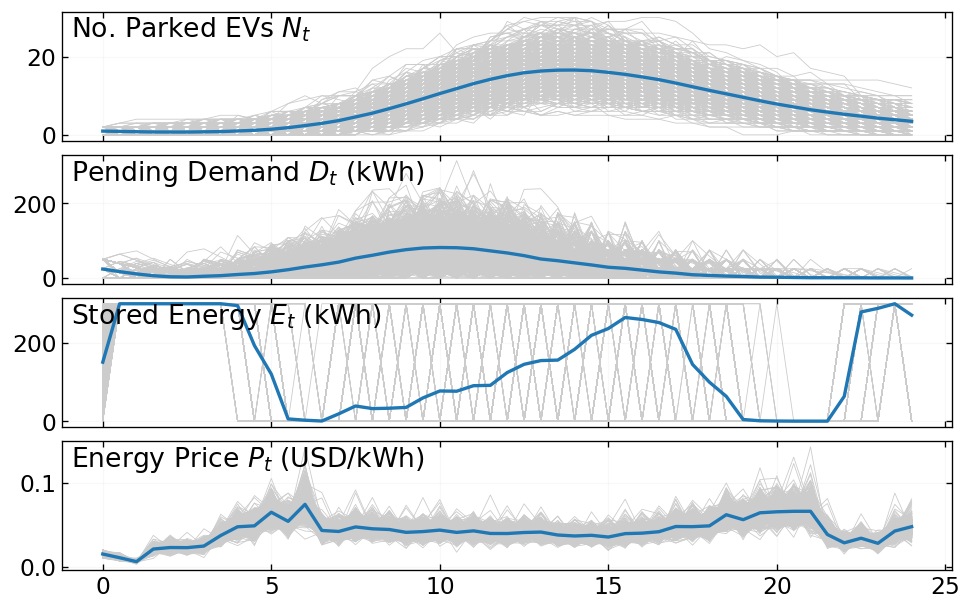

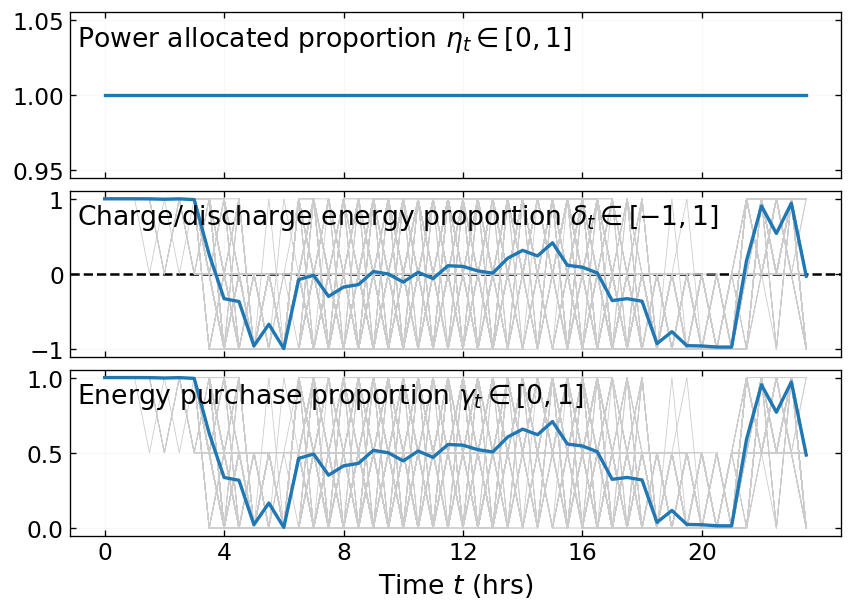

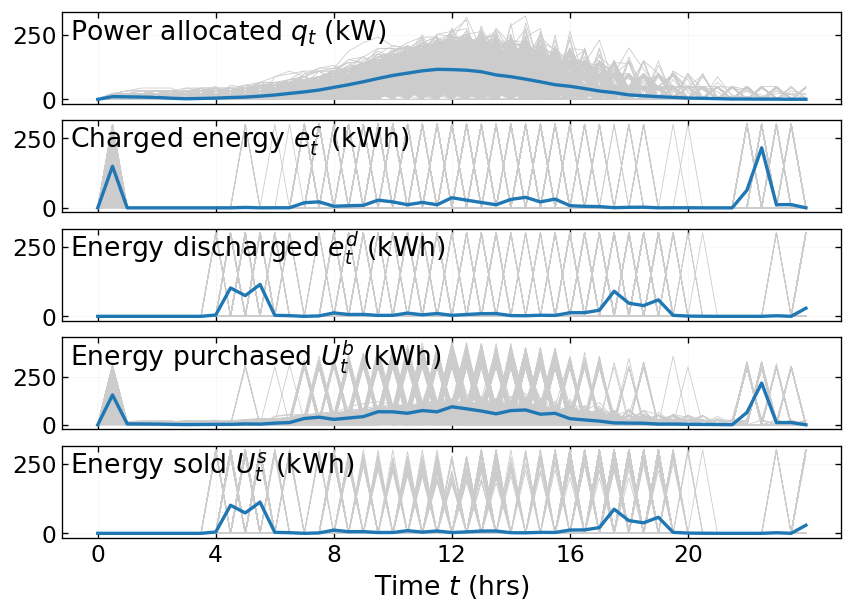

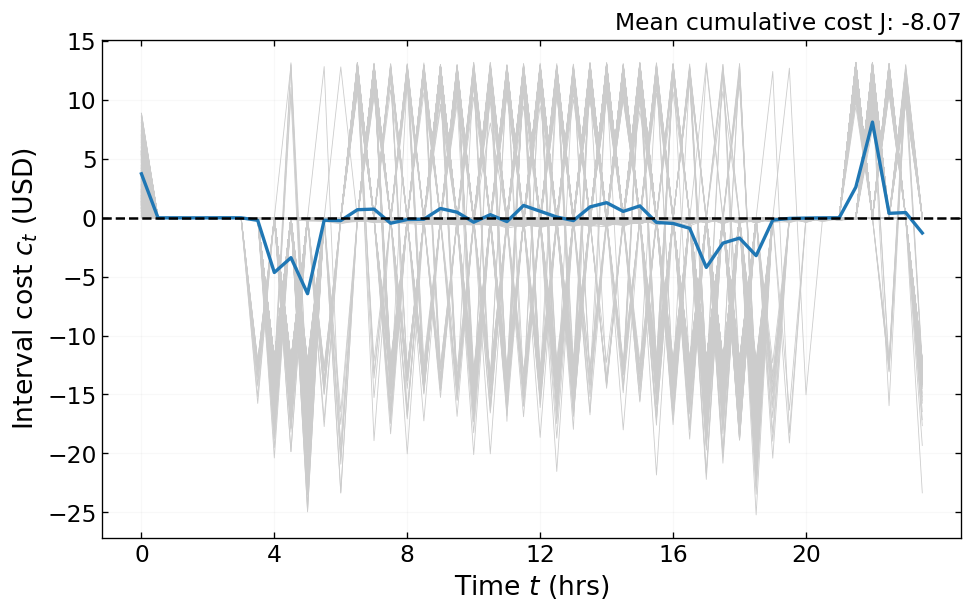

In [5]:
plot_state_trajectories(
    history, save_path="../figures/heuristic_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/heuristic_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/heuristic_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/heuristic_policy/cost.pdf"
)

### Battery Aware Policy

In [6]:
next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

policy = BatteryAwarePolicy()

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["battery_aware"] = history

In [7]:
check_energy_balance(history, params.dt)

{'max_abs_error': 1.52587890625e-05,
 'mean_abs_error': 9.653519761343432e-09,
 'mean_Ub': 44.9732551574707,
 'max_Ub': 432.0}

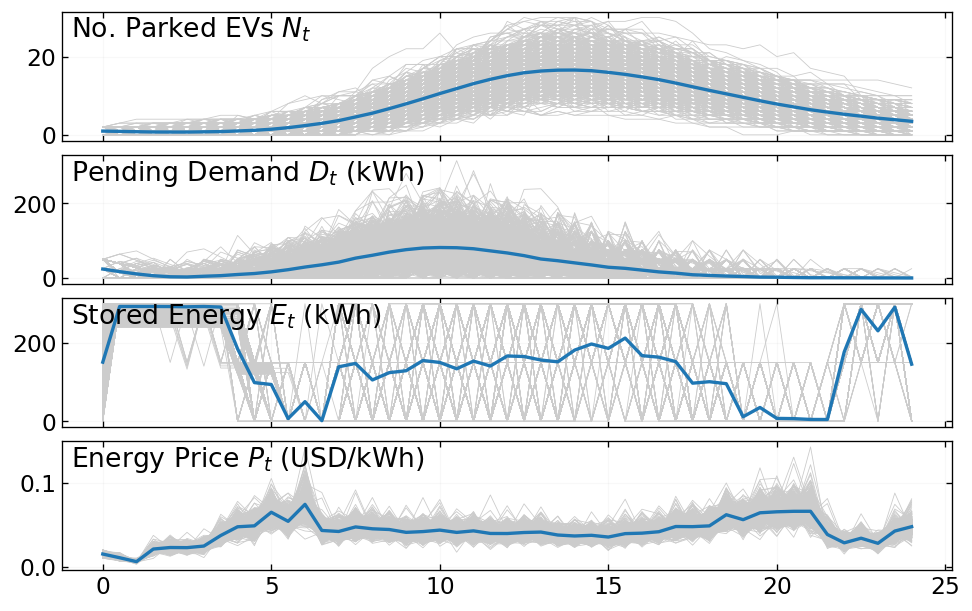

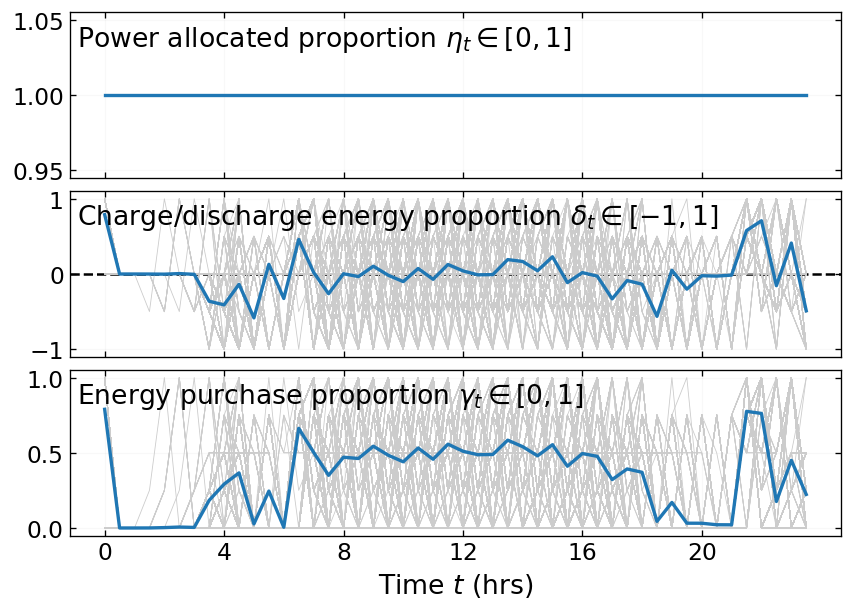

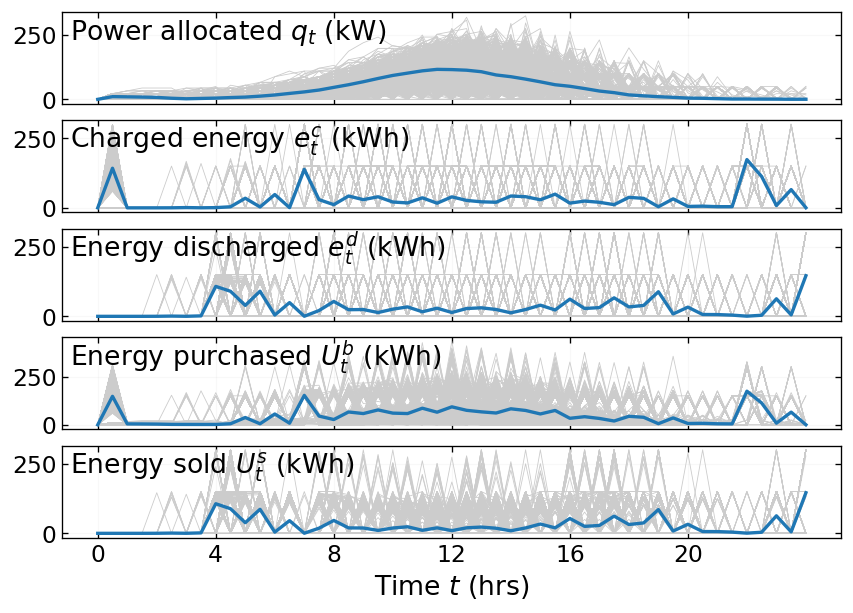

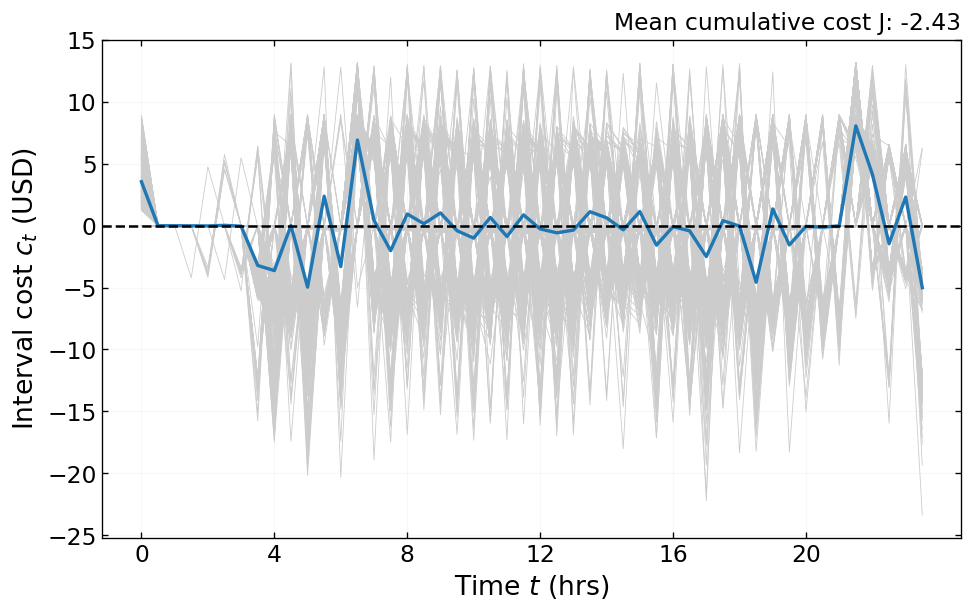

In [8]:
plot_state_trajectories(history)
plot_control_trajectories(history)
plot_endogenous_trajectories(history)
plot_cost_trajectories(history)

### Time Aware Policy

In [9]:
next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

policy = TimeAwarePolicy()

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["time_aware"] = history

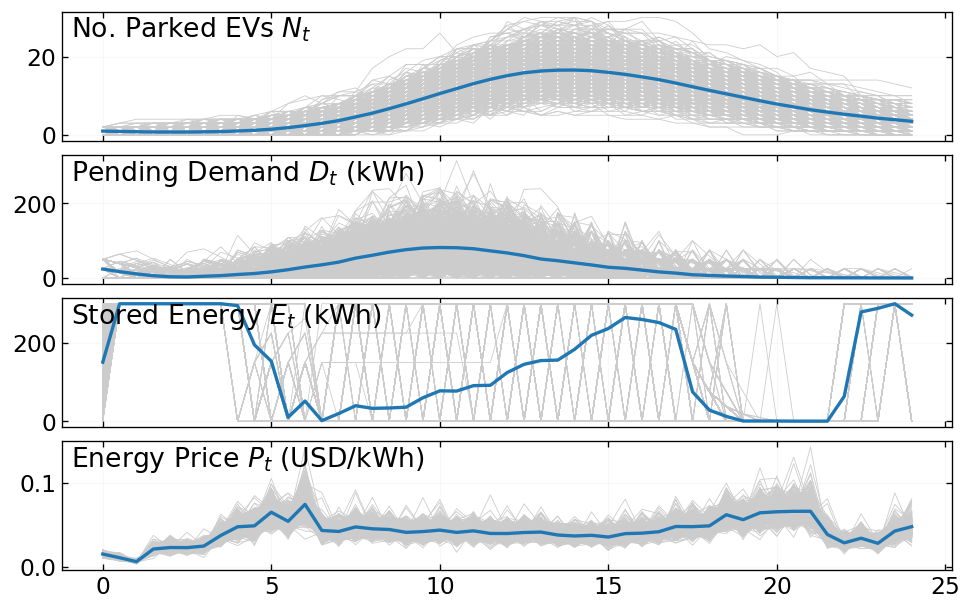

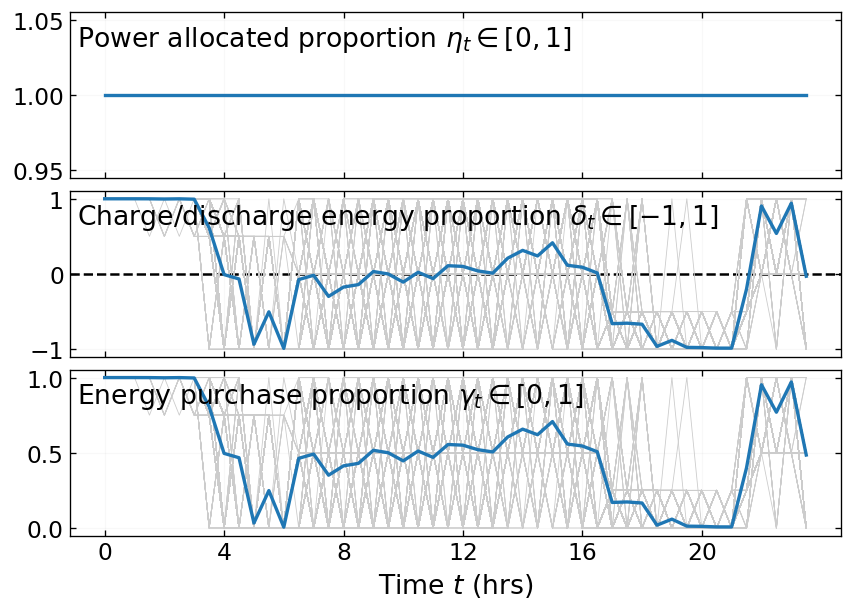

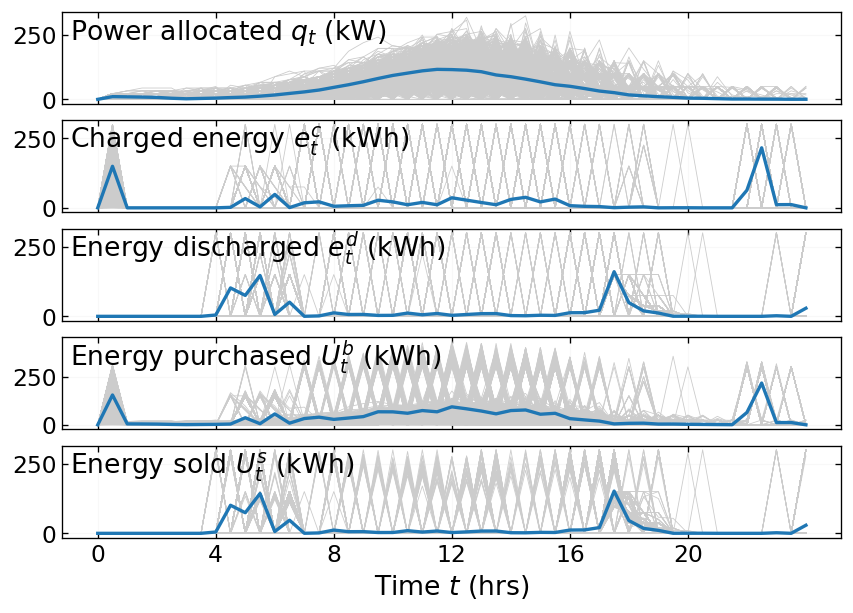

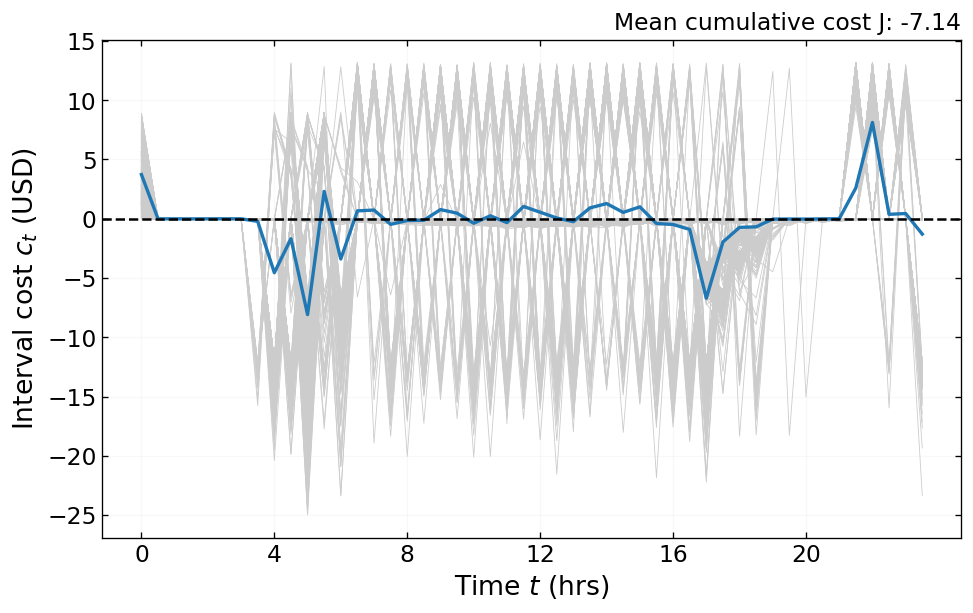

In [10]:
check_energy_balance(history, params.dt)

plot_state_trajectories(history)
plot_control_trajectories(history)
plot_endogenous_trajectories(history)
plot_cost_trajectories(history)

## Untrained Neural Policy 

In [11]:
from pathlib import Path
import torch

In [12]:
torch.manual_seed(global_seed)
policy = NeuralPolicy()

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "seed": global_seed,
        "state_dict": policy.state_dict(),
        "description": "Fixed untrained policy baseline"
    },
    checkpoint_dir / "untrained_policy.pt"
)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])
policy.eval()

next_price_function = make_price_function(
    endog_history=price_history,
    future_endog=future_price,
    params=params
)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_function,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    stochastic=True,
    seed=global_seed,
    device=device
)

results["untrained"] = history

In [13]:
check_energy_balance(history, params.dt)

{'max_abs_error': 3.814697265625e-06,
 'mean_abs_error': 1.1500047136792091e-08,
 'mean_Ub': 17.252437591552734,
 'max_Ub': 99.58191680908203}

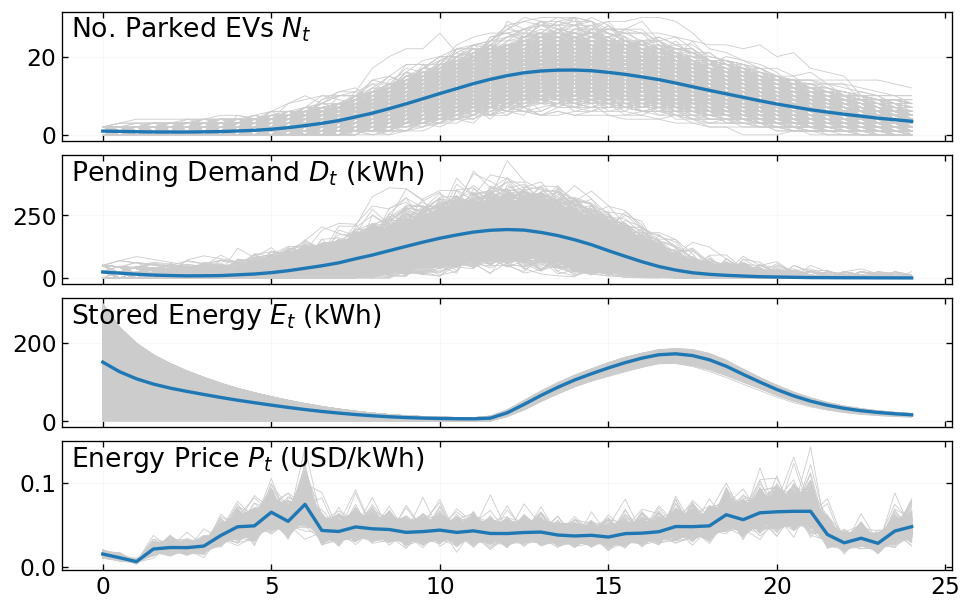

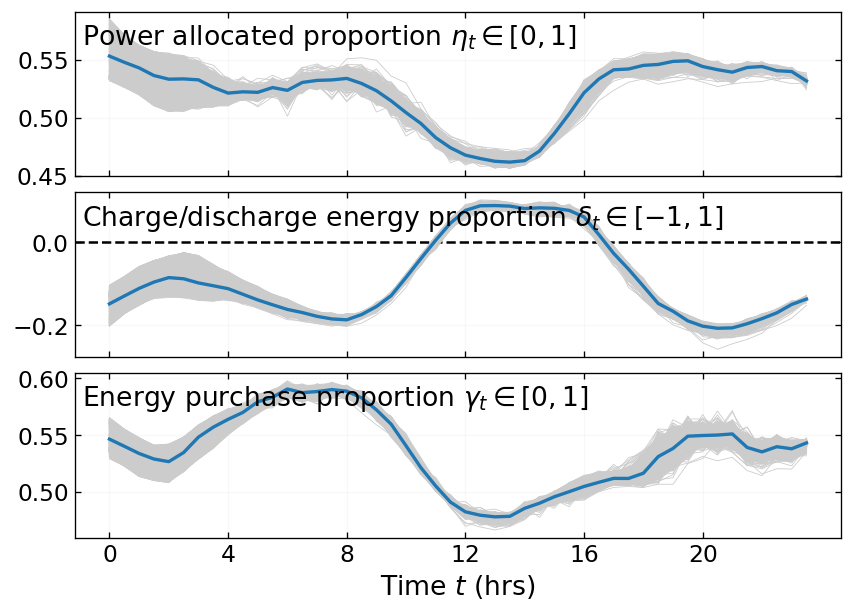

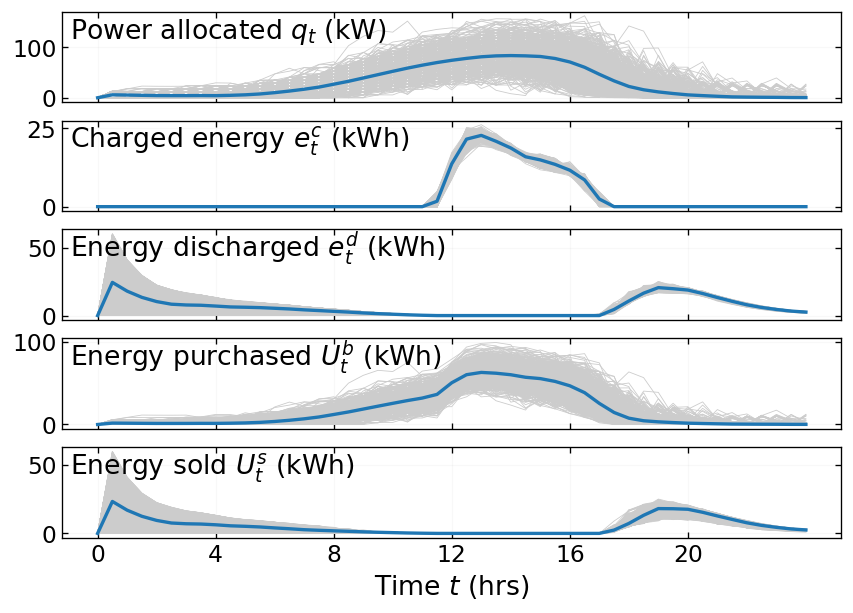

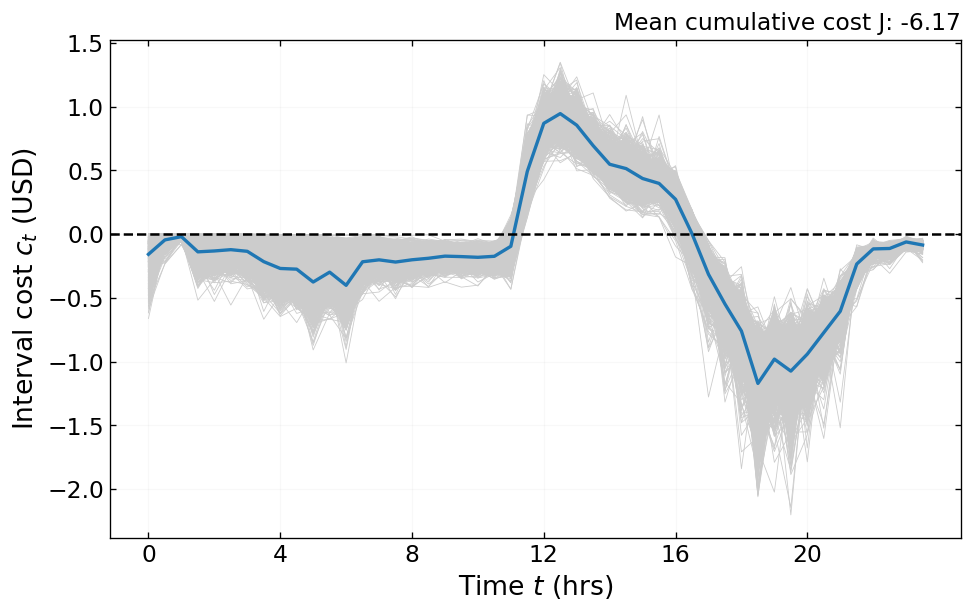

In [14]:
plot_state_trajectories(
    history, save_path="../figures/untrained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/untrained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/untrained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/untrained_policy/cost.pdf"
)

## Trained Neural Policy

In [15]:
from source.training import train_net

EPOCHS = 1000

S0_single = torch.tensor([[0., 0., 100., 0.01]], device=device)

checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["state_dict"])

optimizer = torch.optim.AdamW(
    policy.parameters(),
    lr=5e-4,
    weight_decay=1e-5
)

res = train_net(
    policy=policy,
    optimizer=optimizer,
    device=device,
    params=params,
    S0_single=S0_single,
    endog_history=price_history,
    future_endog=future_price,
    epochs=EPOCHS,
    batch_size=batch_size,
    lambda_cost=0.0,
    lambda_demand=0.0,
    alpha_grid=0.0,
    verbose=True,
    seed_base=global_seed
)

[050] J_train=-8.8788 | J_stoch_eval_fixed=-8.9793 | J_det_eval=-9.8512
[100] J_train=-12.4193 | J_stoch_eval_fixed=-12.5068 | J_det_eval=-12.9189
[150] J_train=-15.9300 | J_stoch_eval_fixed=-16.0280 | J_det_eval=-13.6740
[200] J_train=-18.2545 | J_stoch_eval_fixed=-18.2779 | J_det_eval=-15.0502
[250] J_train=-20.0646 | J_stoch_eval_fixed=-20.0835 | J_det_eval=-18.2064
[300] J_train=-21.5707 | J_stoch_eval_fixed=-21.4870 | J_det_eval=-18.6940
[350] J_train=-22.5794 | J_stoch_eval_fixed=-22.6066 | J_det_eval=-10.6914
[400] J_train=-23.5941 | J_stoch_eval_fixed=-23.4322 | J_det_eval=-10.8121
[450] J_train=-24.5226 | J_stoch_eval_fixed=-24.4473 | J_det_eval=-10.0867
[500] J_train=-25.6462 | J_stoch_eval_fixed=-25.5675 | J_det_eval=-8.5670
[550] J_train=-26.0774 | J_stoch_eval_fixed=-26.0775 | J_det_eval=-8.4008
[600] J_train=-26.2789 | J_stoch_eval_fixed=-26.3787 | J_det_eval=-8.1340
[650] J_train=-26.9001 | J_stoch_eval_fixed=-26.5940 | J_det_eval=-7.8911
[700] J_train=-27.2063 | J_stoch

In [16]:
from pathlib import Path
import torch

checkpoint_dir = Path("../checkpoints/policies")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint = {
    "best_J": res["best_J"],
    "policy_state_dict": res["best_state"],
    "J_train_hist": res["J_train_hist"],
    'J_stoch_eval_hist': res['J_stoch_eval_hist'],
    'J_det_eval_hist': res['J_det_eval_hist'],
    "training_steps": res["training_steps"],
    "evaluation_steps": res["evaluation_steps"],
    "seed_base": global_seed,
    "epochs": EPOCHS,
    "batch_size": batch_size,
    "lr": 5e-4,
    "weight_decay": 1e-5,
}

torch.save(checkpoint, checkpoint_dir / "trained_policy.pt")

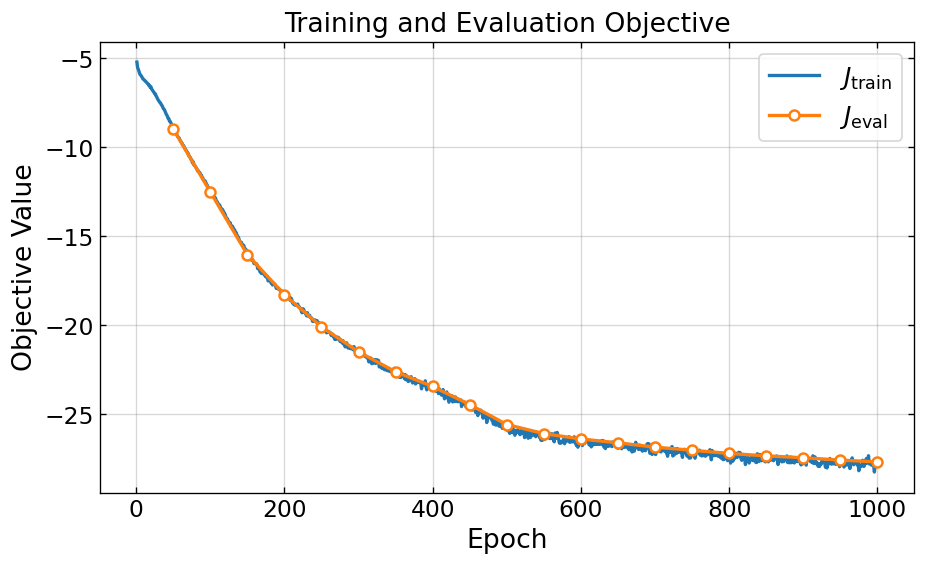

In [17]:
import os

SAVE_DIR = "../figures/trained_policy"
os.makedirs(SAVE_DIR, exist_ok=True)

J_train = checkpoint["J_train_hist"]
J_evaluation = checkpoint["J_stoch_eval_hist"]

training_steps = checkpoint["training_steps"]
evaluation_steps = checkpoint["evaluation_steps"]

fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(training_steps, J_train, linewidth=2, label=r"$J_{\mathrm{train}}$")

ax.plot(
    evaluation_steps, J_evaluation,
    marker="o", markerfacecolor="white",
    markeredgewidth=1.5, linewidth=2,
    label=r"$J_{\mathrm{eval}}$"
)

ax.set_xlabel("Epoch")
ax.set_ylabel("Objective Value")
ax.set_title("Training and Evaluation Objective")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

fig.savefig(
    os.path.join(SAVE_DIR, "training_curve.pdf"),
    bbox_inches="tight"
)

fig.savefig(
    os.path.join(SAVE_DIR, "training_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
checkpoint = torch.load(
    "../checkpoints/policies/trained_policy.pt",
    map_location=device
)

policy = NeuralPolicy().to(device)
policy.load_state_dict(checkpoint["policy_state_dict"])
policy.eval()

next_price_fn = make_price_function(price_history, future_price, params)

history = rollout_trajectory(
    policy=policy,
    S0=S0,
    params=params,
    next_price_fn=next_price_fn,
    stochastic=True,
    alpha_grid=0.0,
    lambda_demand=0.0,
    lambda_cost=0.0,
    seed=global_seed,
    device=device,
)

results["trained"] = history

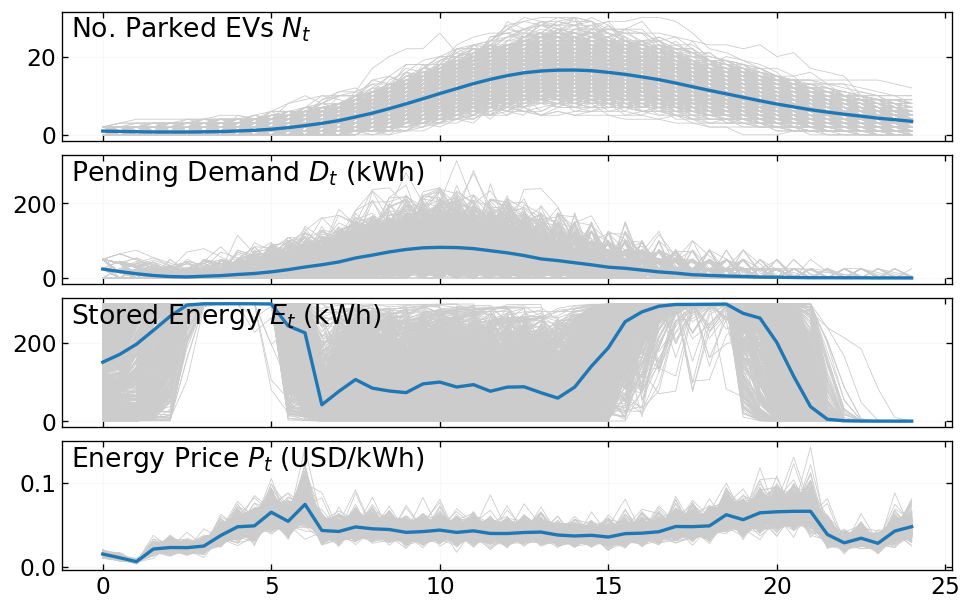

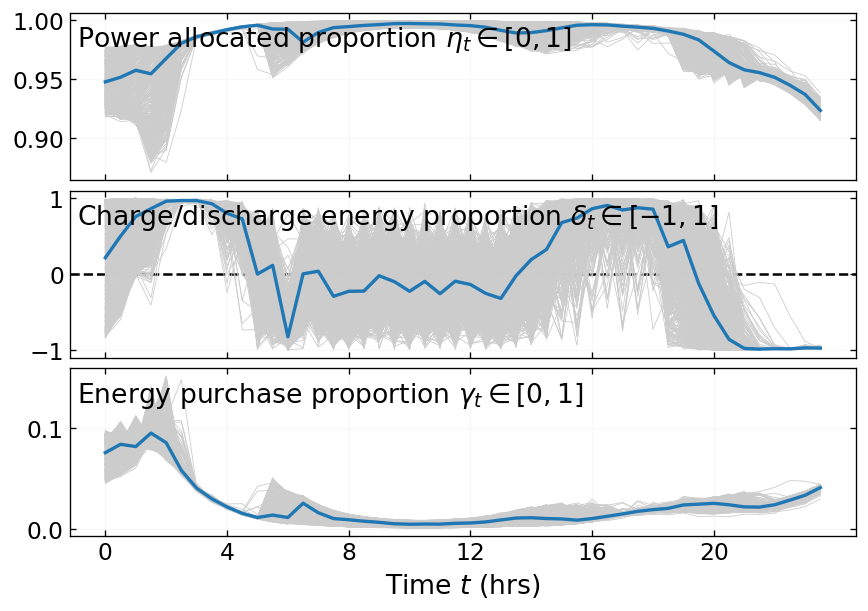

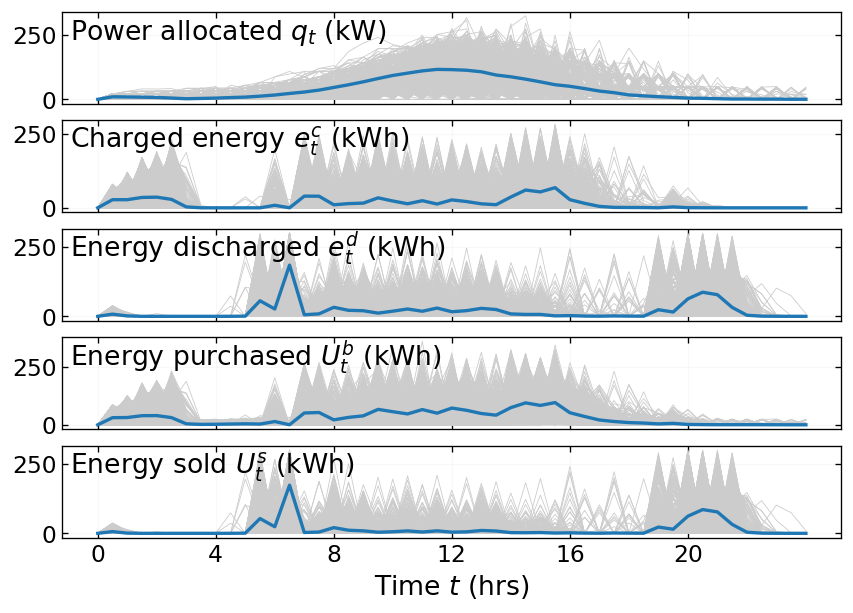

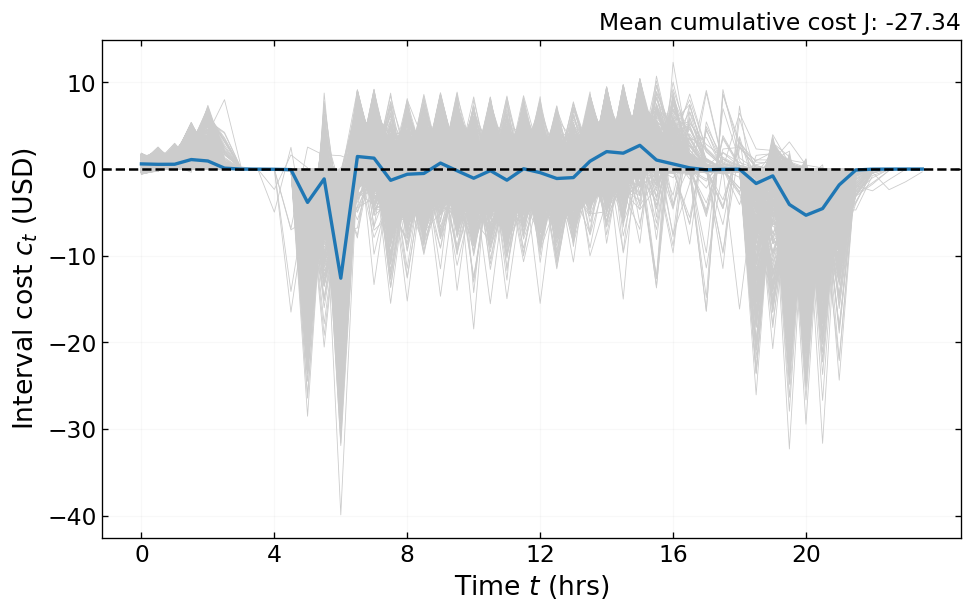

In [19]:
plot_state_trajectories(
    history, save_path="../figures/trained_policy/states.pdf"
)
plot_control_trajectories(
    history, save_path="../figures/trained_policy/controls.pdf"
)
plot_endogenous_trajectories(
    history, save_path="../figures/trained_policy/endogenous.pdf"
)
plot_cost_trajectories(
    history, save_path="../figures/trained_policy/cost.pdf"
)

In [20]:
rollout_dir = Path("../checkpoints/rollouts")
rollout_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    results,
    rollout_dir / "policy_comparison.pt"
)

# Policy comparison

In [3]:
import sys
sys.path.append("..")

import torch
from source.plotting import *

device = torch.device("cpu")

results = torch.load(
    "../checkpoints/rollouts/policy_comparison.pt",
    map_location=device
)

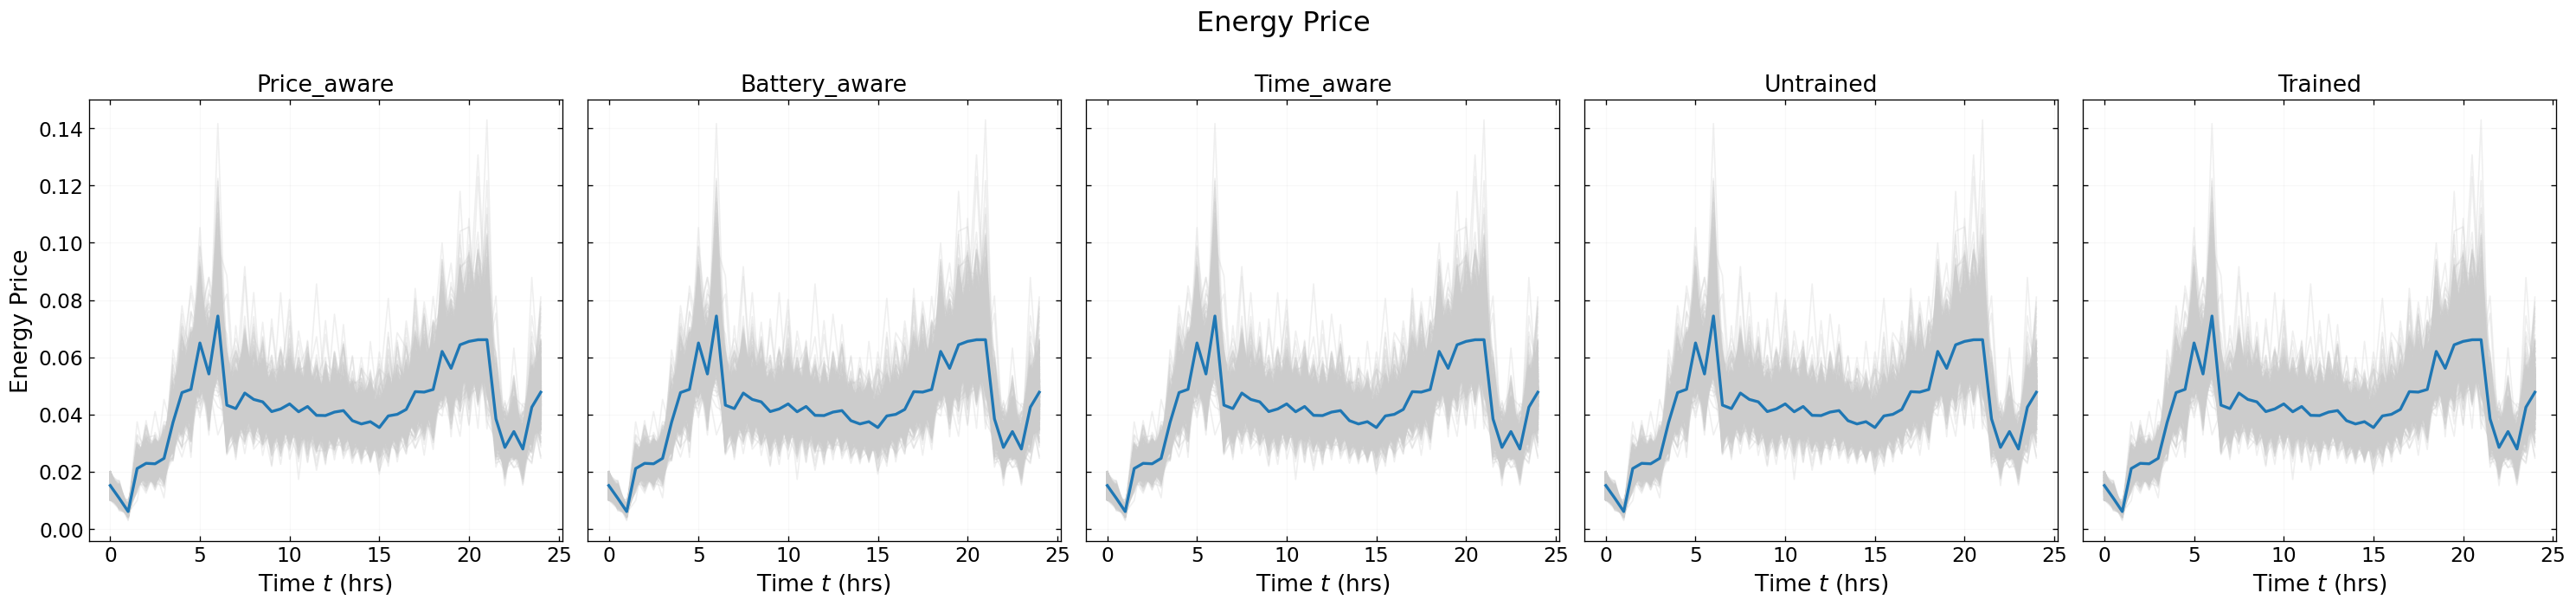

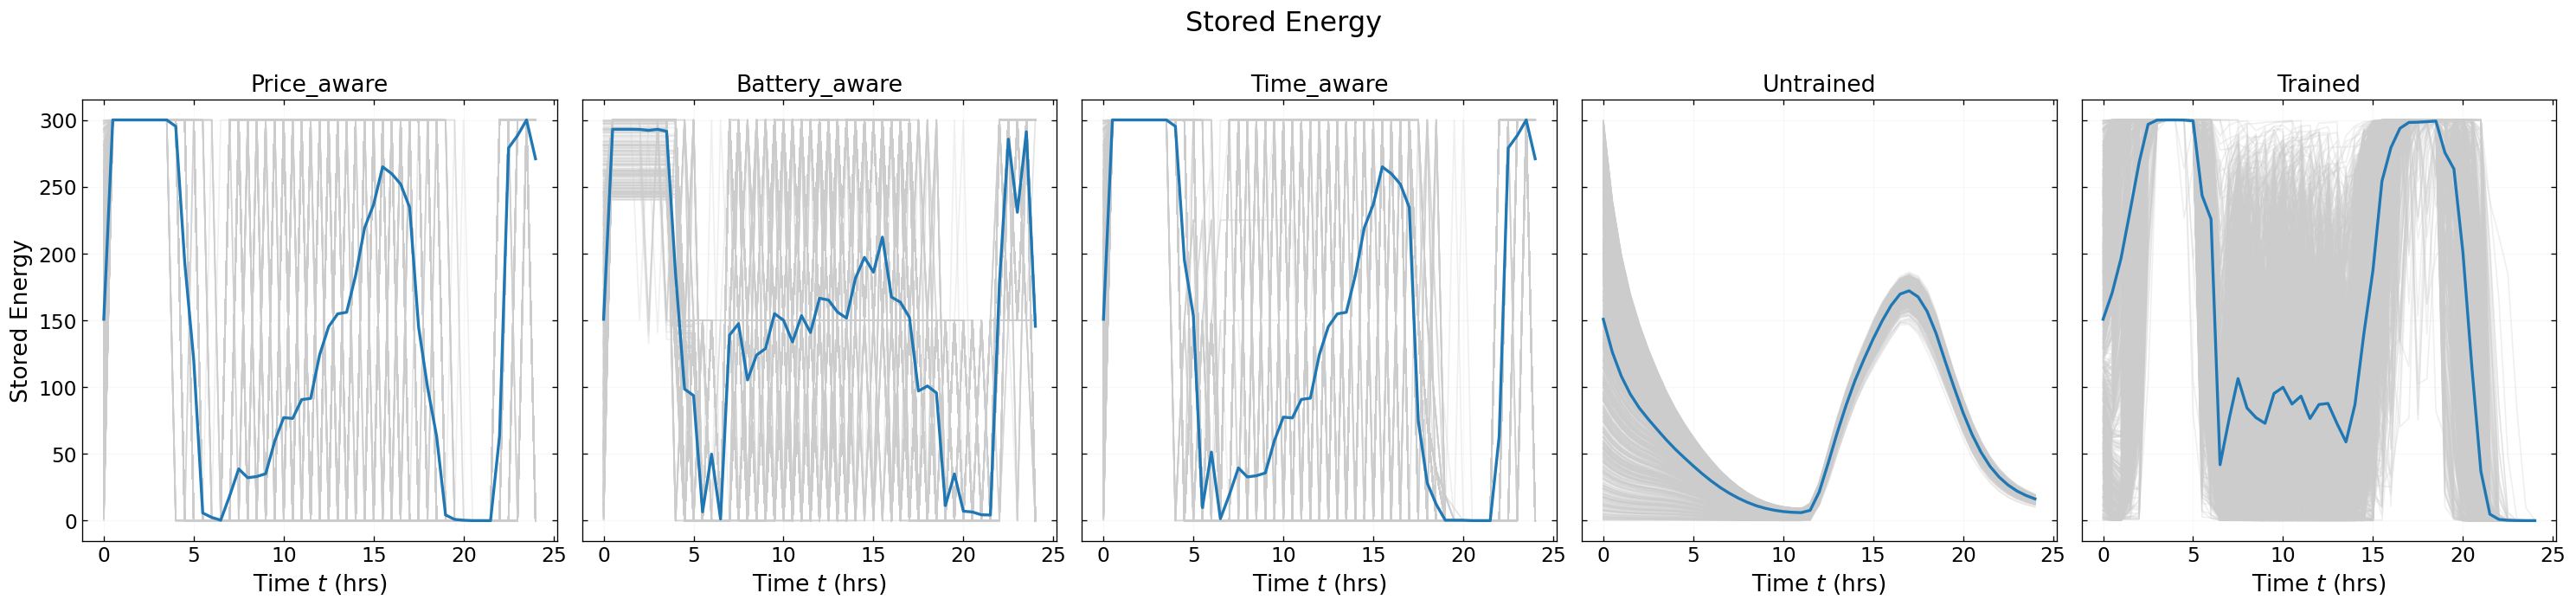

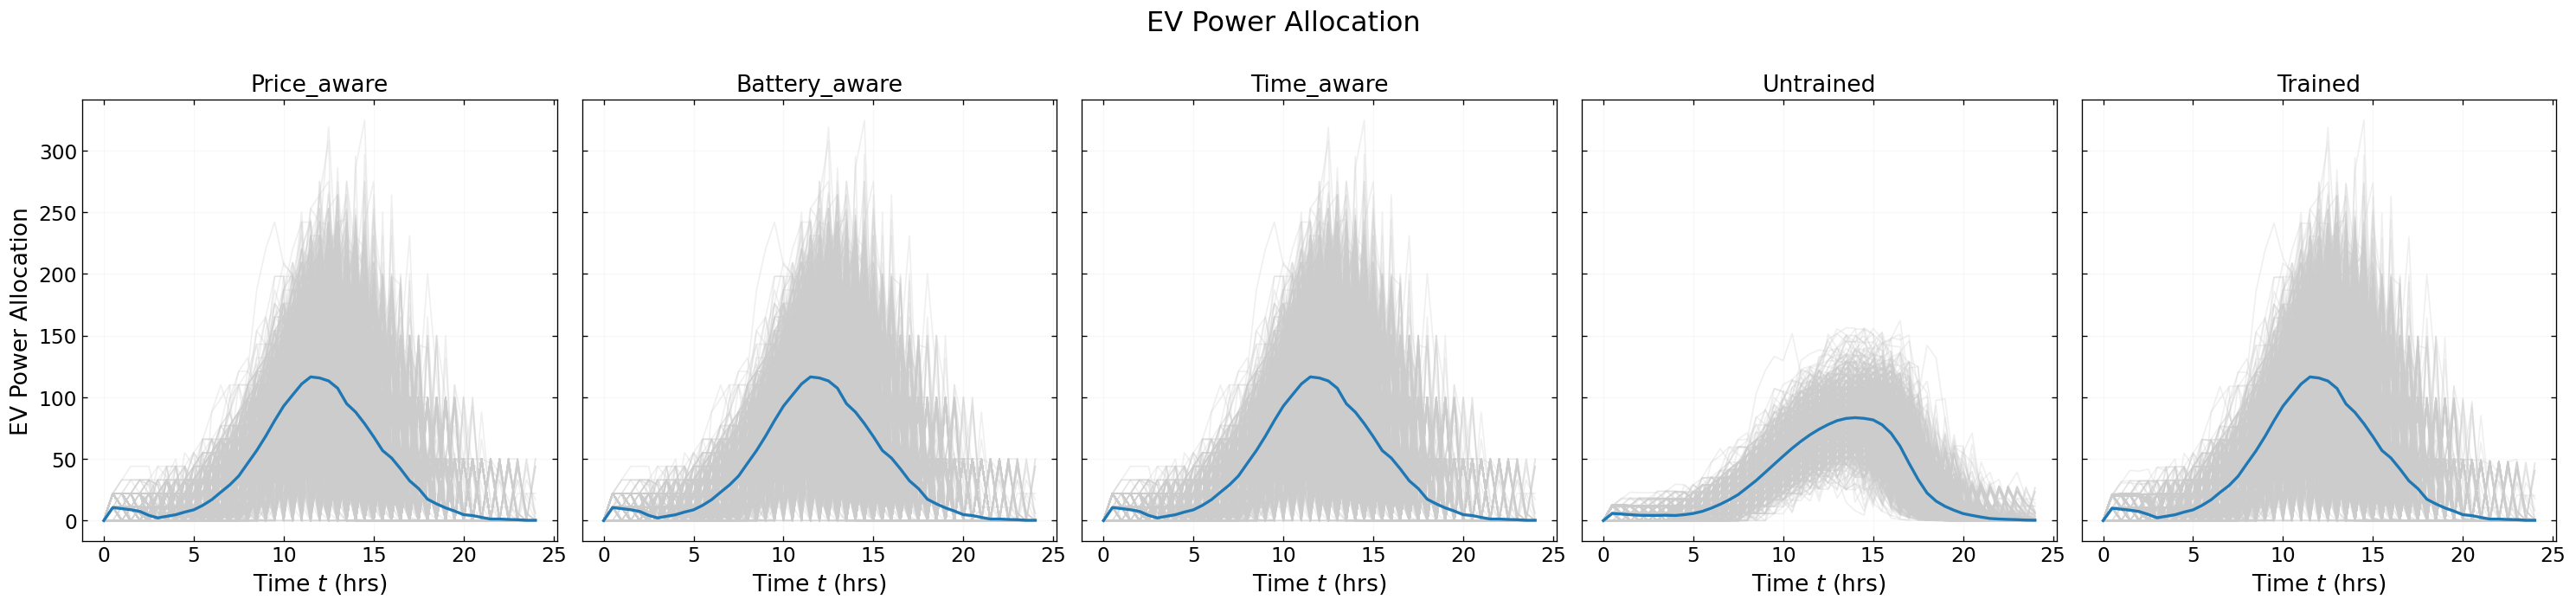

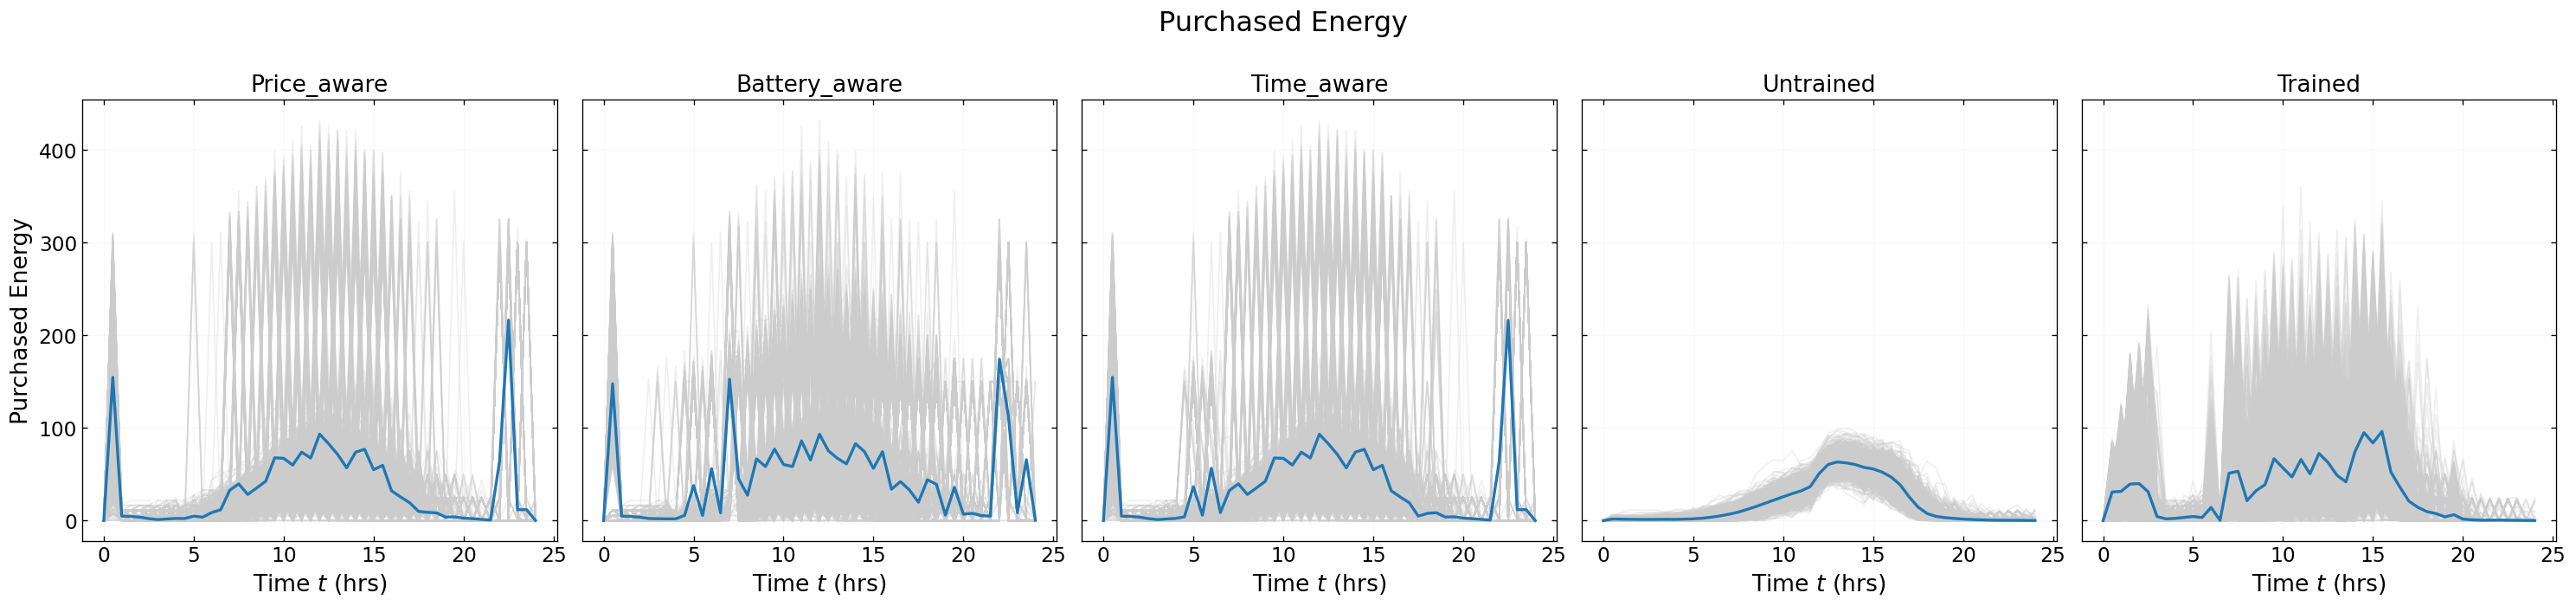

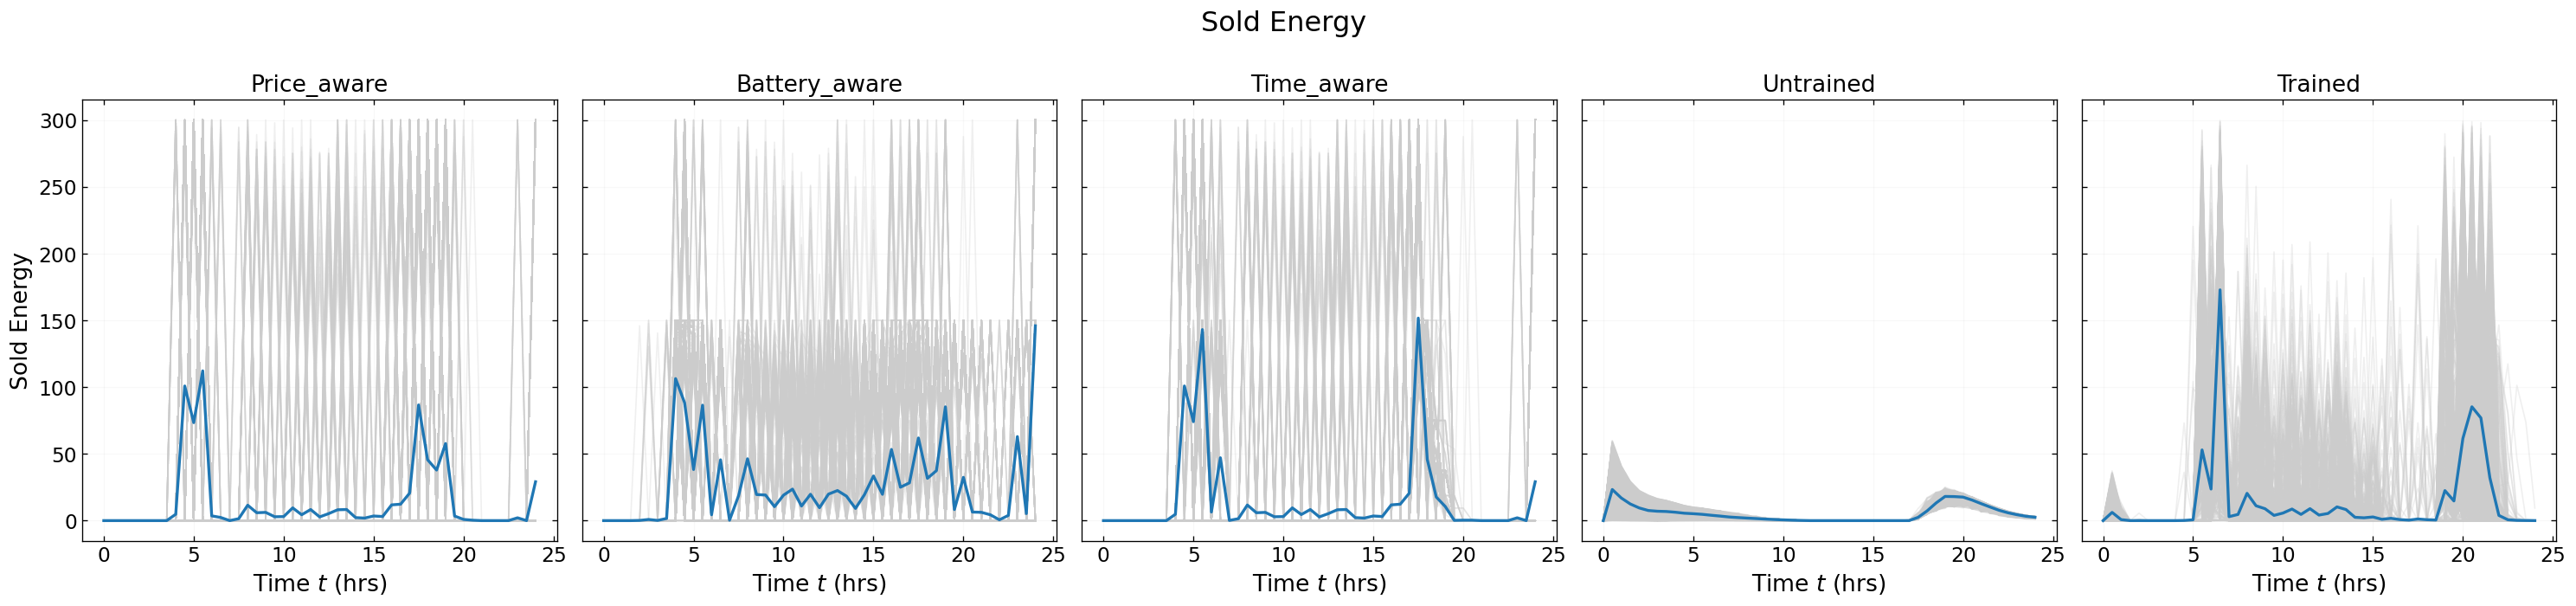

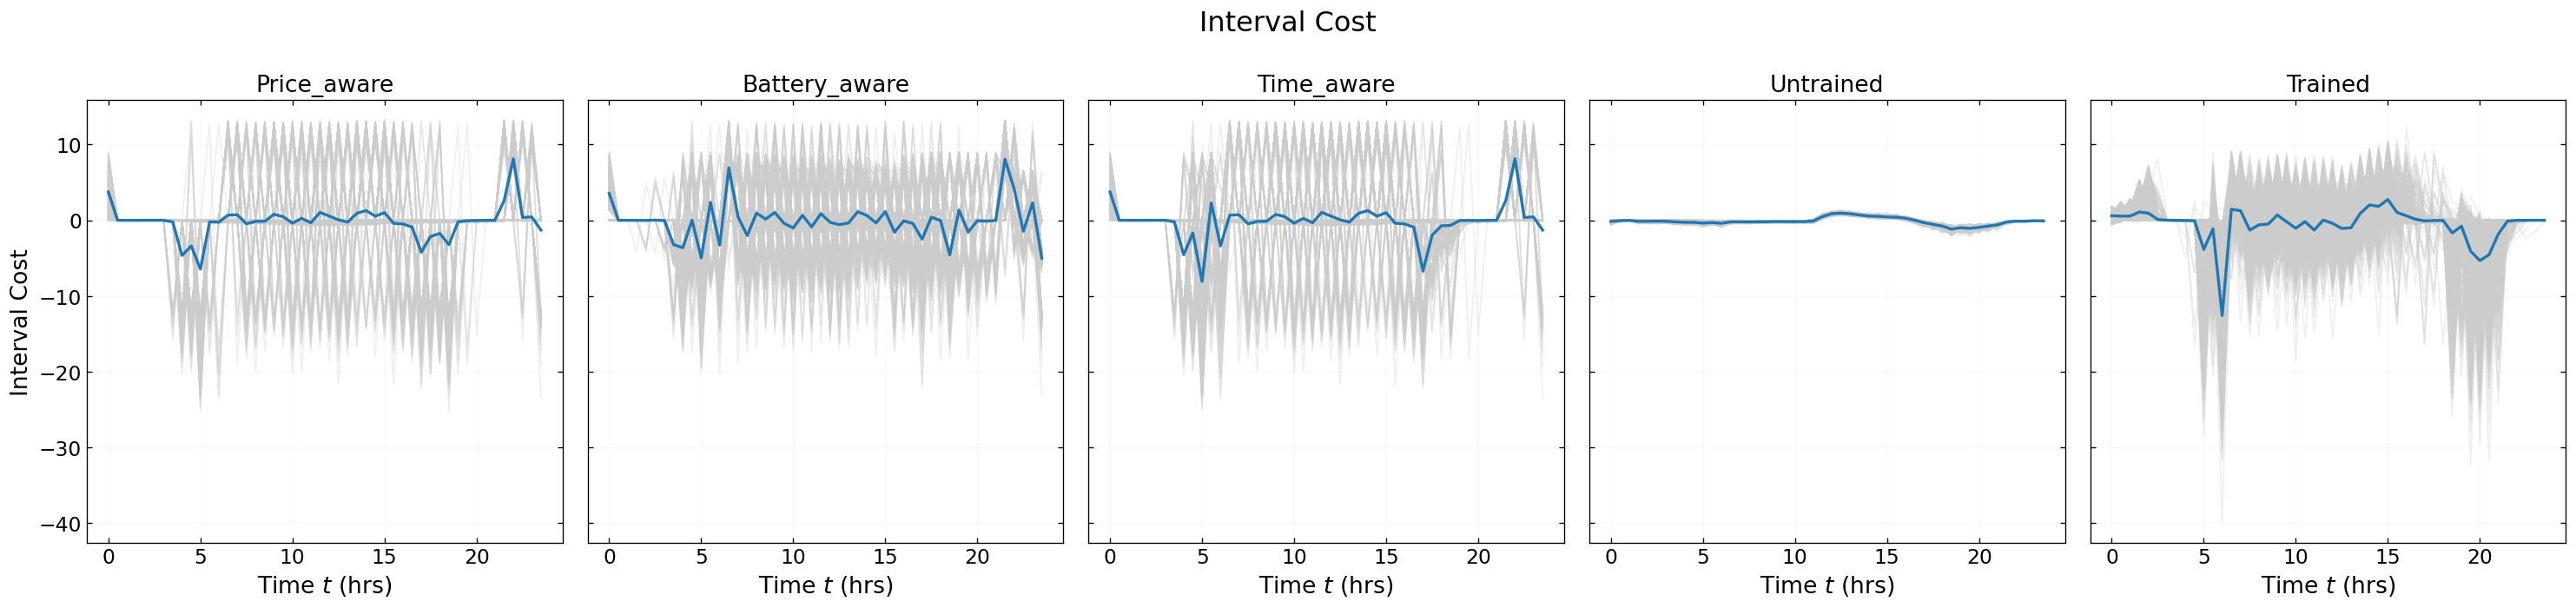

(<Figure size 3000x720 with 5 Axes>,
 array([<Axes: title={'center': 'Price_aware'}, xlabel='Time $t$ (hrs)', ylabel='Interval Cost'>,
        <Axes: title={'center': 'Battery_aware'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Time_aware'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Untrained'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Trained'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [23]:
plot_variable_across_policies(
    results,
    "P",
    "Energy Price",
    #"../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "E",
    "Stored Energy",
    "../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "q",
    "EV Power Allocation",
    "../figures/policy_comparison/ev_power_allocation.pdf"
)

plot_variable_across_policies(
    results,
    "Ub",
    "Purchased Energy",
    "../figures/policy_comparison/purchased_energy.pdf"
)

plot_variable_across_policies(
    results,
    "Us",
    "Sold Energy",
    "../figures/policy_comparison/sold_energy.pdf"
)

plot_variable_across_policies(
    results,
    "c",
    "Interval Cost",
    "../figures/policy_comparison/interval_cost.pdf"
)

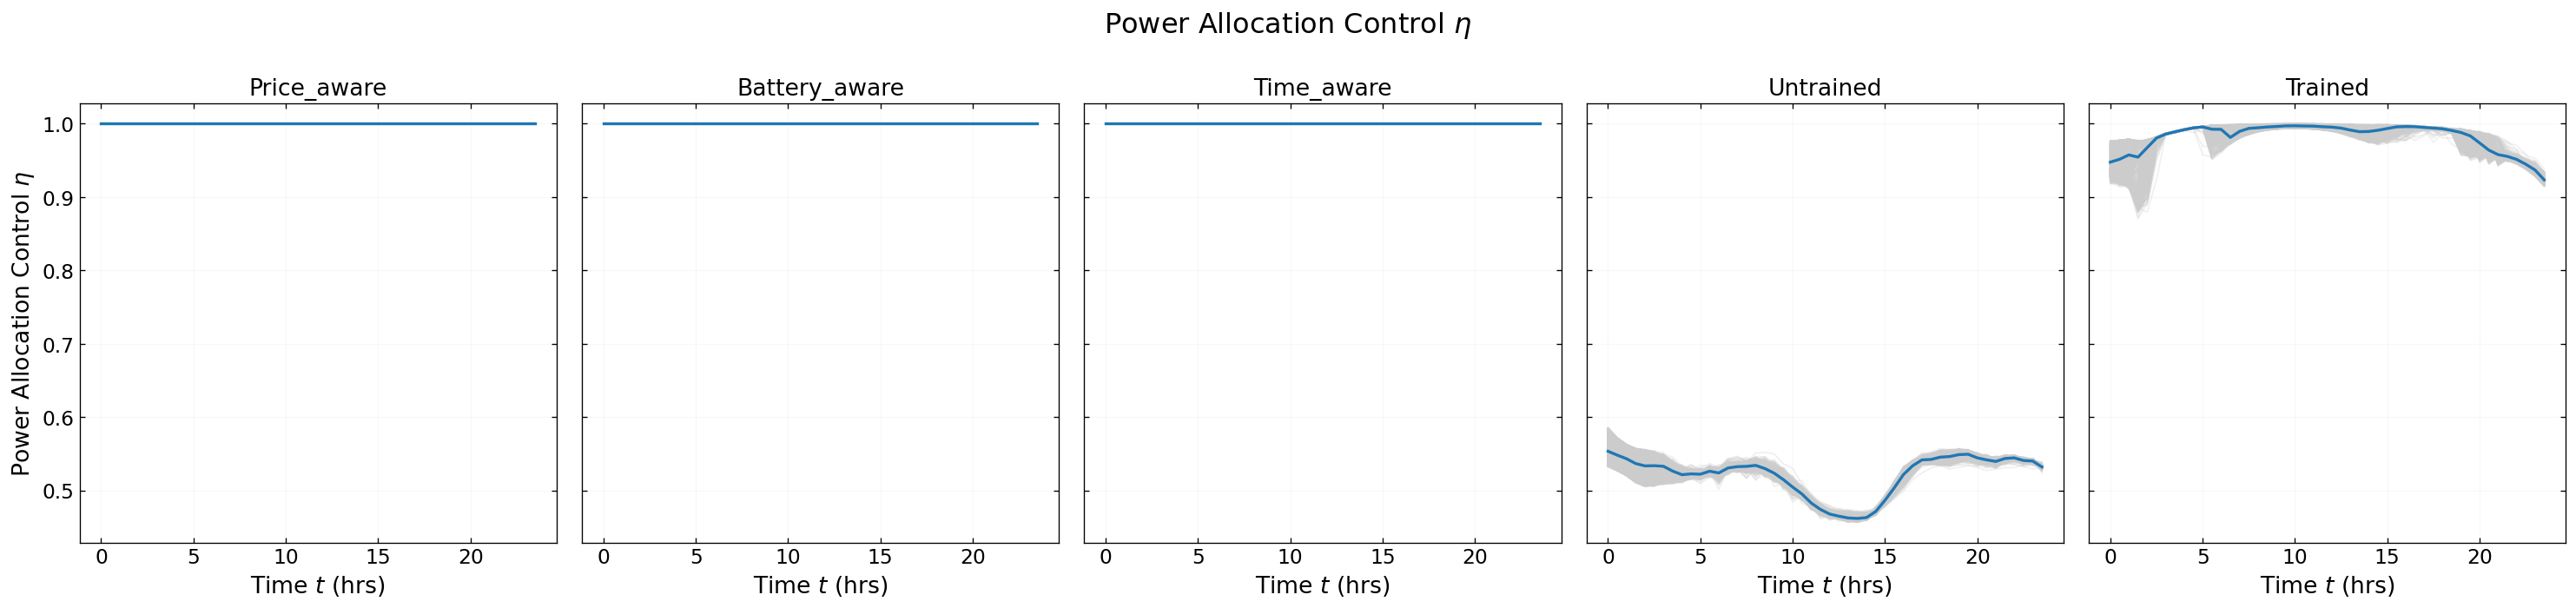

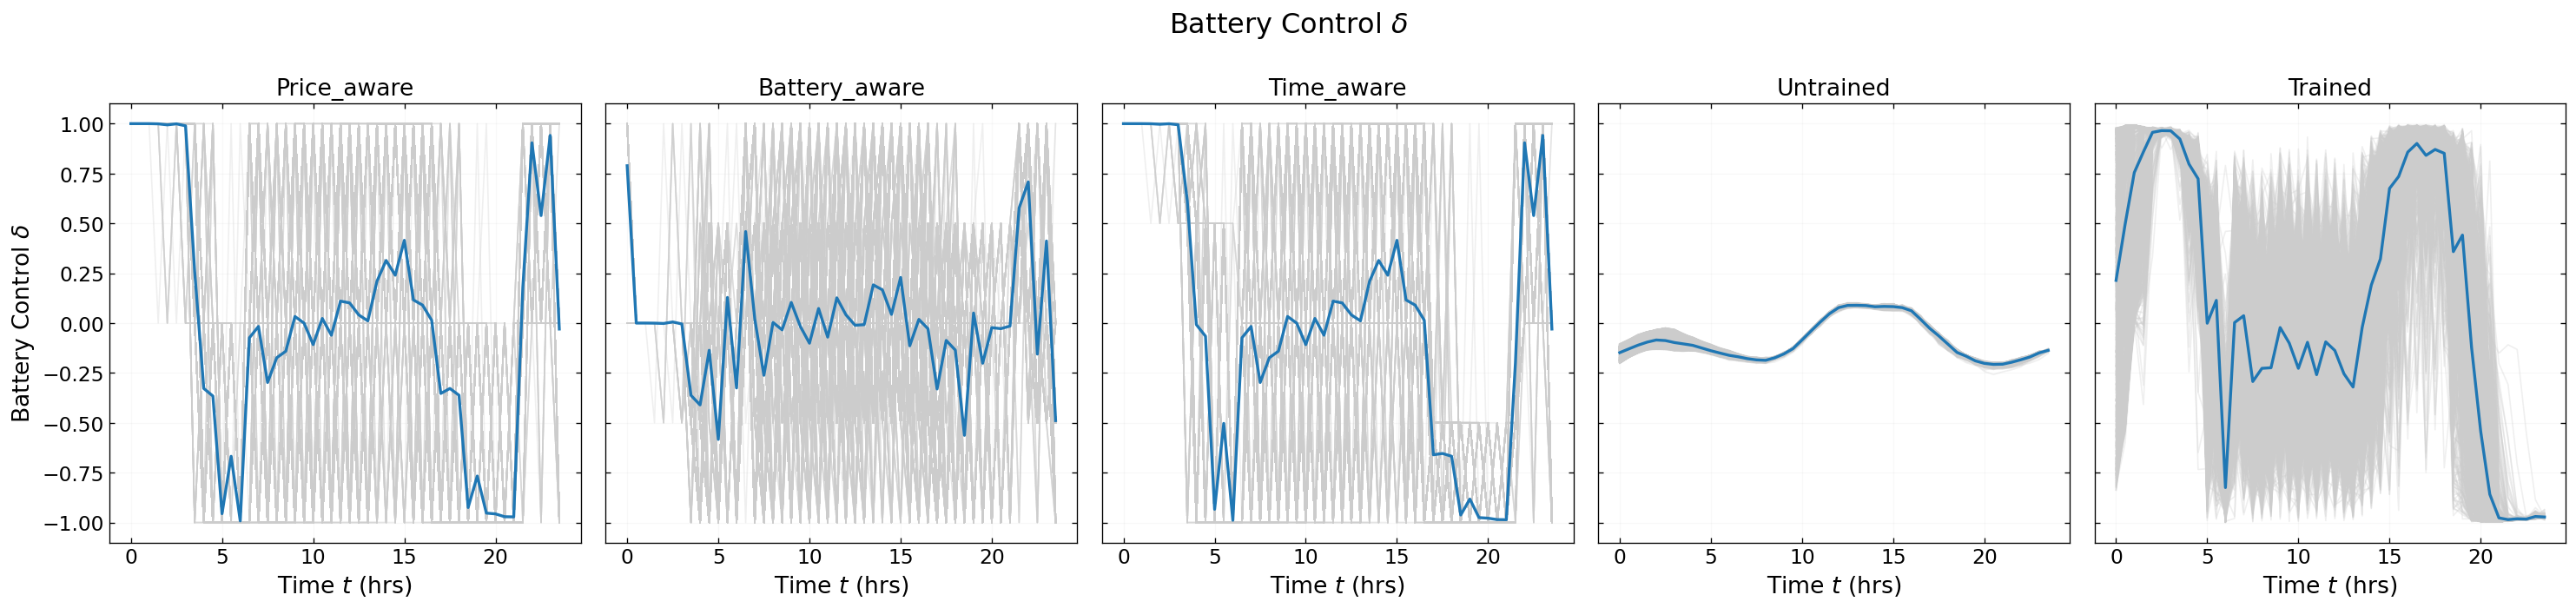

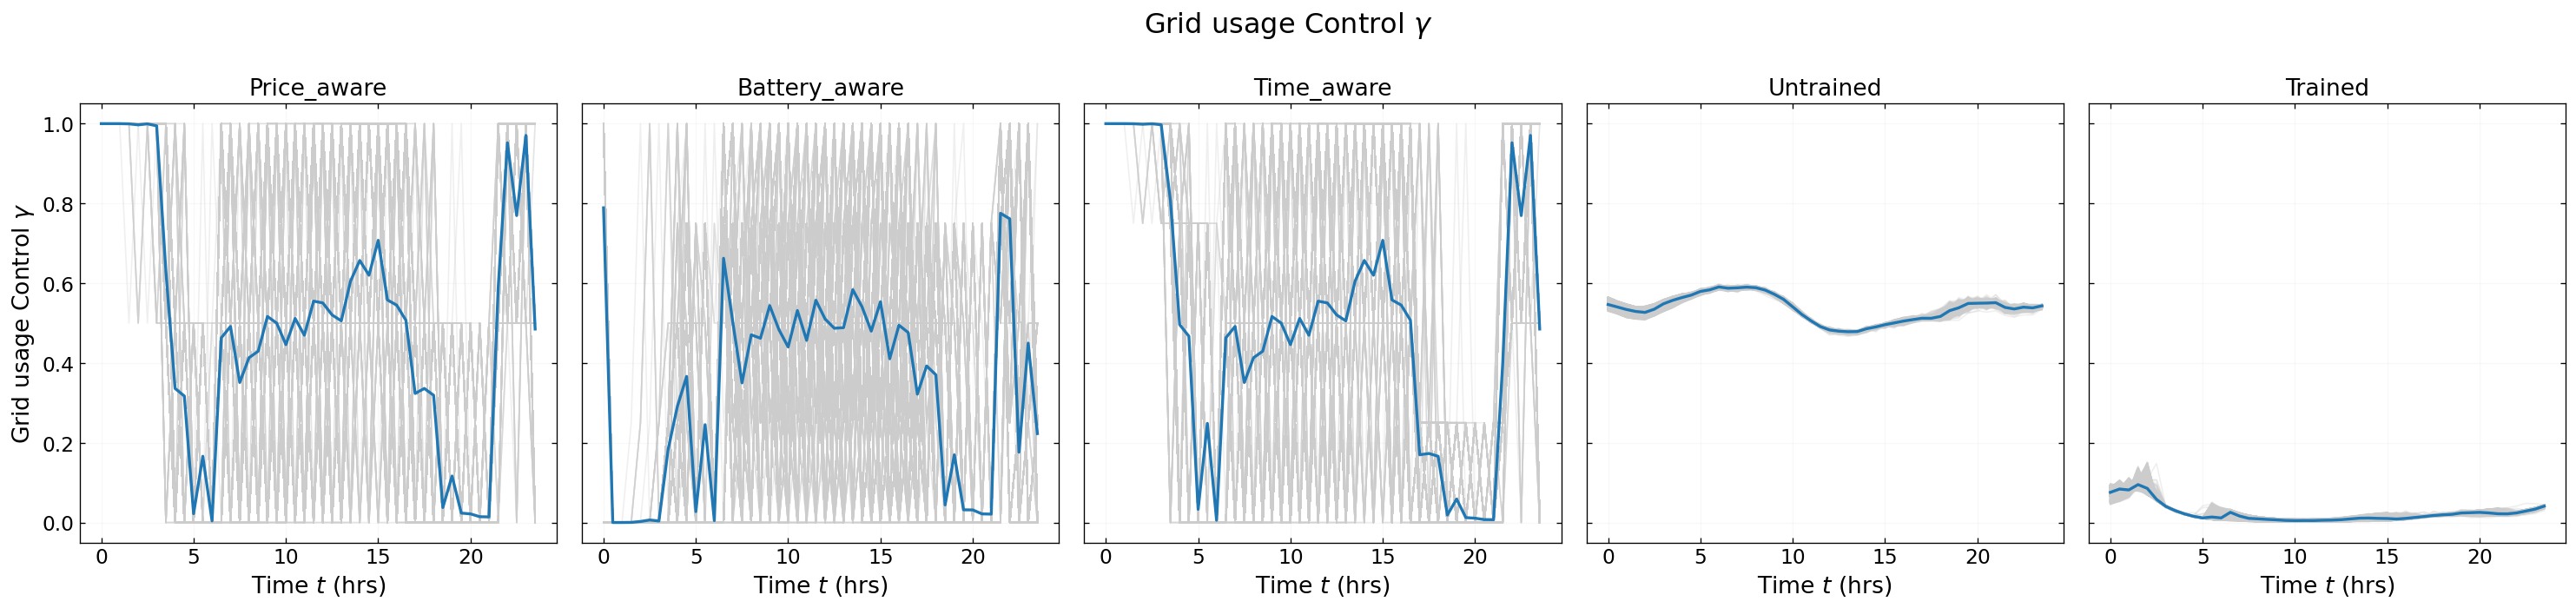

(<Figure size 3000x720 with 5 Axes>,
 array([<Axes: title={'center': 'Price_aware'}, xlabel='Time $t$ (hrs)', ylabel='Grid usage Control $\\gamma$'>,
        <Axes: title={'center': 'Battery_aware'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Time_aware'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Untrained'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'center': 'Trained'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [24]:
plot_variable_across_policies(
    results,
    "eta",
    "Power Allocation Control $\eta$",
    #"../figures/policy_comparison/stored_energy.pdf"
)

plot_variable_across_policies(
    results,
    "delta",
    "Battery Control $\delta$",
    #"../figures/policy_comparison/ev_power_allocation.pdf"
)

plot_variable_across_policies(
    results,
    "gamma",
    "Grid usage Control $\gamma$",
    #"../figures/policy_comparison/purchased_energy.pdf"
)

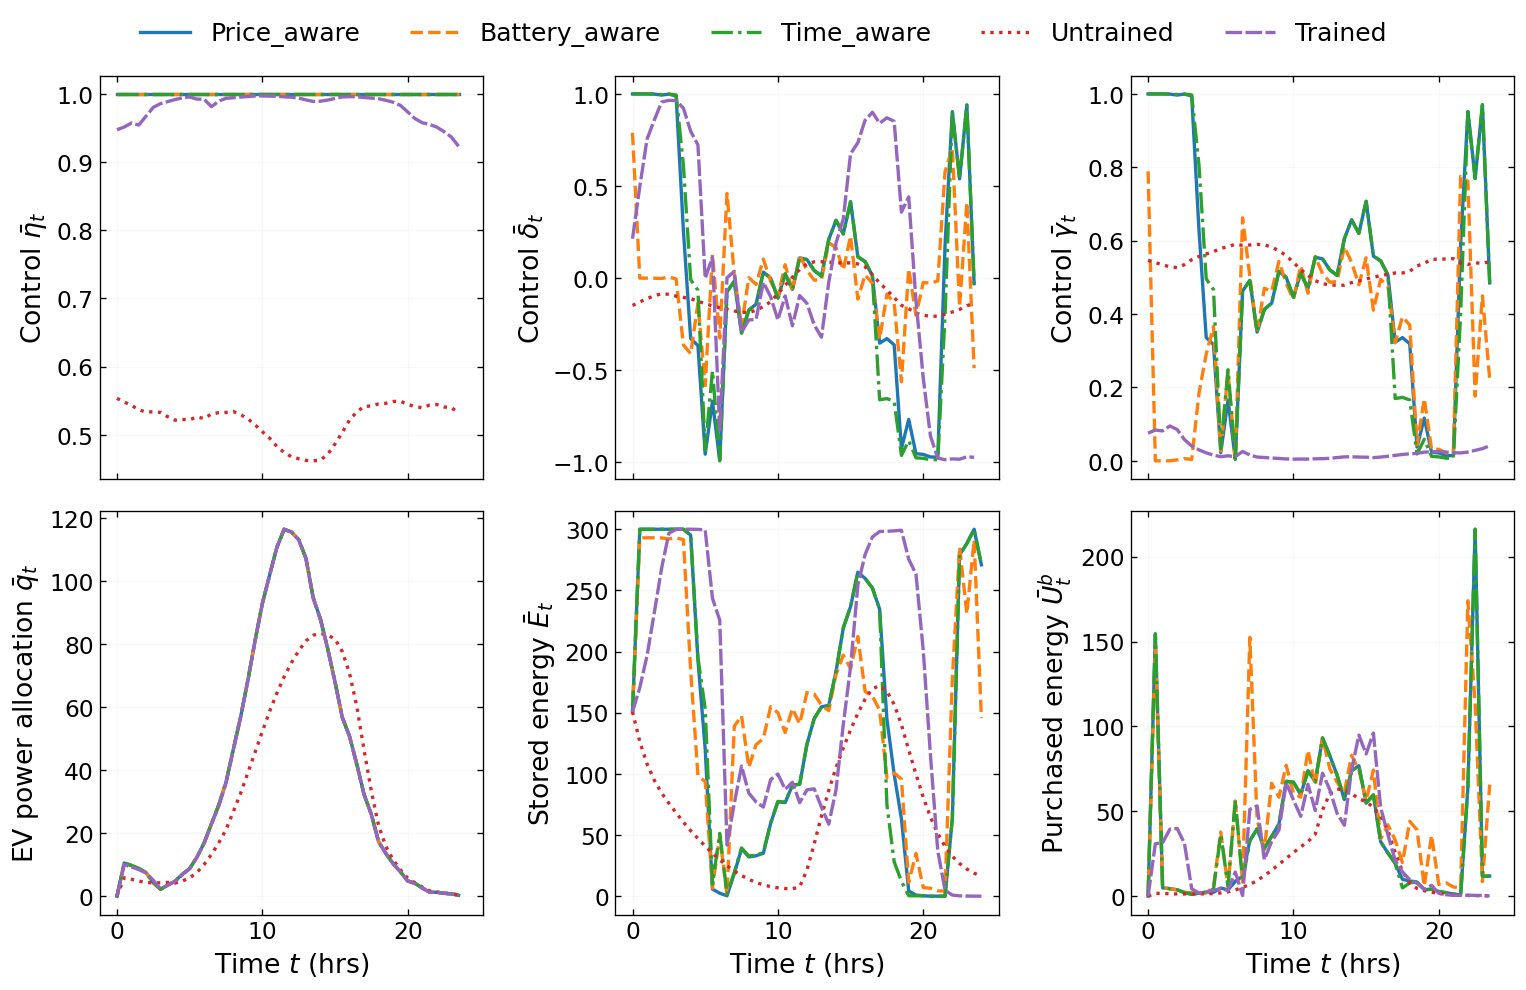

(<Figure size 1560x960 with 6 Axes>,
 array([<Axes: ylabel='Control $\\bar{\\eta}_t$'>,
        <Axes: ylabel='Control $\\bar{\\delta}_t$'>,
        <Axes: ylabel='Control $\\bar{\\gamma}_t$'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='EV power allocation $\\bar{q}_t$'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='Stored energy $\\bar{E}_t$'>,
        <Axes: xlabel='Time $t$ (hrs)', ylabel='Purchased energy $\\bar{U}^{b}_t$'>],
       dtype=object))

In [ ]:

plot_controls_summary(
    results,
    "../figures/policy_comparison/controls_summary.pdf"
)

In [5]:
from source.utils import summarize_histories

df = summarize_histories(results)
print(df.round(4))

            price_aware  battery_aware  time_aware  untrained   trained
N_mean           7.6744         7.6744      7.6744     7.6744    7.6744
N_std            6.1878         6.1878      6.1878     6.1878    6.1878
D_mean          27.2015        27.2015     27.2015    61.4483   27.4087
D_std           37.8387        37.8387     37.8387    75.5498   37.9991
E_mean         146.2502       151.0681    144.1357    68.8598  159.8571
E_std          148.9382       106.2685    146.6842    57.8821  126.9547
P_mean           0.0420         0.0420      0.0420     0.0420    0.0420
P_std            0.0157         0.0157      0.0157     0.0157    0.0157
eta_mean         1.0000         1.0000      1.0000     0.5212    0.9815
eta_std          0.0000         0.0000      0.0000     0.0279    0.0210
delta_mean       0.0150        -0.0073      0.0073    -0.0875    0.0907
delta_std        0.7190         0.4945      0.7385     0.0993    0.7164
gamma_mean       0.5075         0.3374      0.5037     0.5363   

In [6]:
import os

SAVE_DIR = "../checkpoints/rollouts"
os.makedirs(SAVE_DIR, exist_ok=True)

df.to_csv(
    os.path.join(
        SAVE_DIR,
        "policy_comparison_summary.csv"
    )
)

with open(
    os.path.join(
        SAVE_DIR,
        "policy_comparison_summary.tex"
    ),
    "w"
) as f:
    f.write(df.round(4).to_latex())

In [7]:
import matplotlib.pyplot as plt
import sys

from source.plotting import *

sys.path.append("..")
plt.style.use("../styles/notebook.mplstyle")

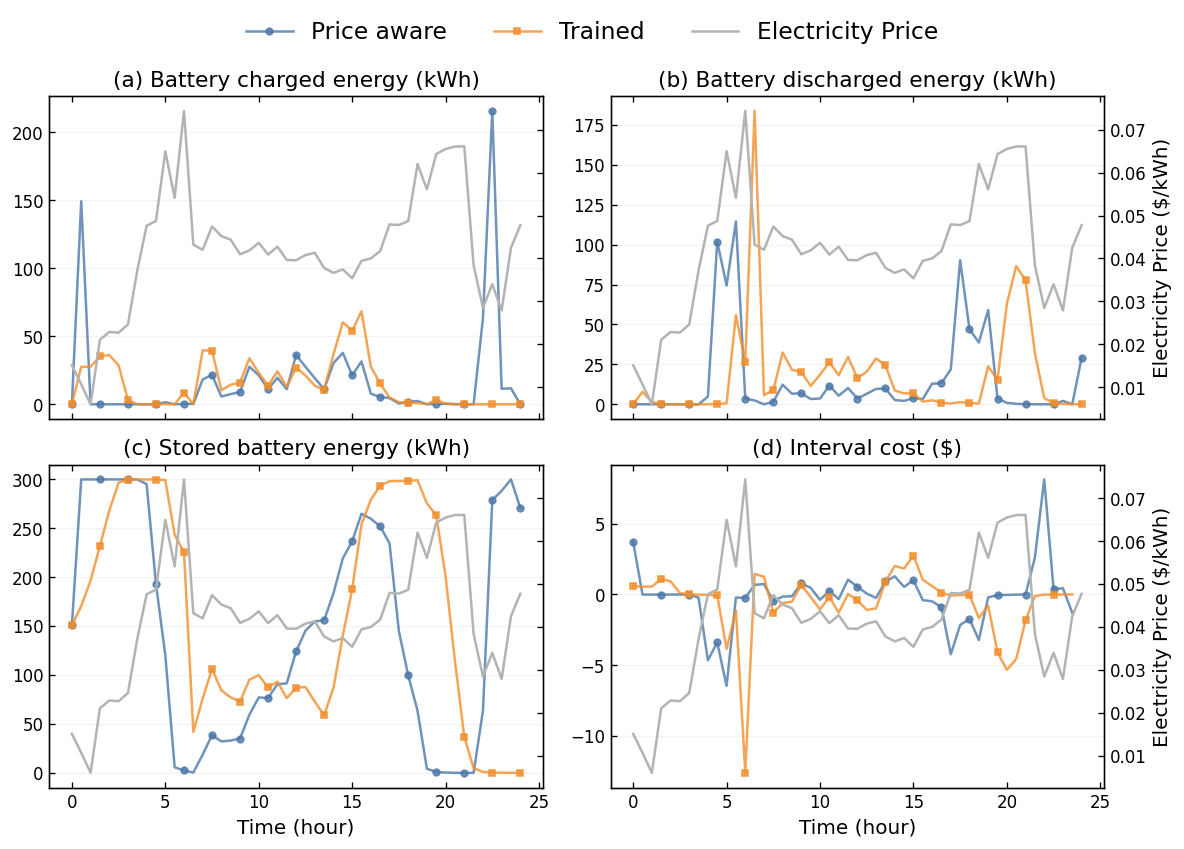

In [ ]:
from pathlib import Path

save_dir = Path("../figures/policy_comparison")
save_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True)

trained_history = results["trained"]
time = trained_history["time"].detach().numpy()
price_mean = trained_history["state"][..., 3].detach().numpy().mean(axis=1)

subset = {k: results[k] for k in ["price_aware", "trained"]}

plots = [
    {
        "ax": axes[0, 0],
        "metric_key": "endog",
        "metric_idx": 1,
        "ylabel": "Battery Charged\nEnergy (kWh)",
        "title": "(a) Battery charged energy (kWh)",
    },
    {
        "ax": axes[0, 1],
        "metric_key": "endog",
        "metric_idx": 2,
        "ylabel": "Battery Discharged\nEnergy (kWh)",
        "title": "(b) Battery discharged energy (kWh)",
    },
    {
        "ax": axes[1, 0],
        "metric_key": "state",
        "metric_idx": 2,
        "ylabel": "Stored Battery\nEnergy (kWh)",
        "title": "(c) Stored battery energy (kWh)",
    },
    {
        "ax": axes[1, 1],
        "metric_key": "cost",
        "metric_idx": None,
        "ylabel": "Interval Cost ($)",
        "title": "(d) Interval cost ($)",
    },
]

legend_handles = None
legend_labels = None

for i, item in enumerate(plots):
    ax1 = item["ax"]

    ax1, handles, labels = plot_policy_metric(
        subset,
        metric_key=item["metric_key"],
        metric_idx=item["metric_idx"],
        ax=ax1,
    )

    ax1.set_title(item["title"])
    if i < 2:
        ax1.set_xlabel("")
    

    ax2 = ax1.twinx()
    line_price = ax2.plot(
        time,
        price_mean,
        color="0.7",
        lw=1.5,
        label="Electricity price",
        zorder=1
    )

    if i % 2 == 1:
        ax2.set_ylabel("Electricity Price ($/kWh)")
    else:
        ax2.set_yticklabels([])
    ax2.grid(False)

    if legend_handles is None:
        legend_handles = handles + line_price
        legend_labels = [l.replace("_"," ").capitalize() for l in labels] + ["Electricity Price"]

fig.legend(
    legend_handles,
    legend_labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.02),
    ncol=4,
    fontsize=14,
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig(save_dir / "policy_comparison_endog_price.pdf", bbox_inches="tight")
plt.show()

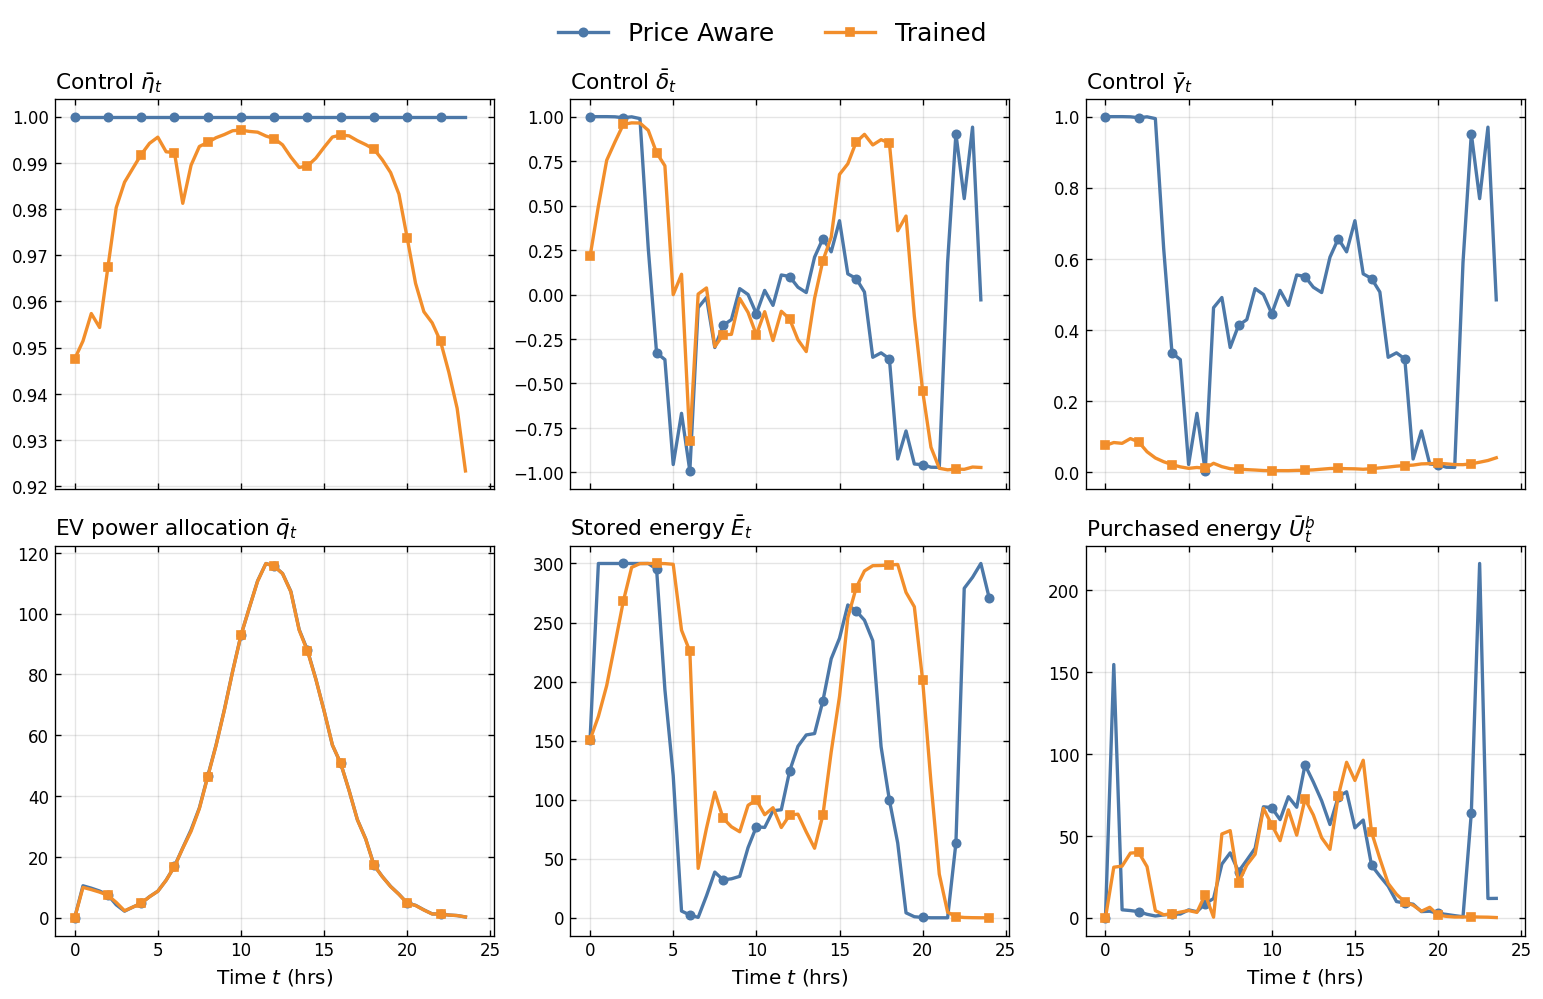

(<Figure size 1560x960 with 6 Axes>,
 array([<Axes: title={'left': 'Control $\\bar{\\eta}_t$'}>,
        <Axes: title={'left': 'Control $\\bar{\\delta}_t$'}>,
        <Axes: title={'left': 'Control $\\bar{\\gamma}_t$'}>,
        <Axes: title={'left': 'EV power allocation $\\bar{q}_t$'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'left': 'Stored energy $\\bar{E}_t$'}, xlabel='Time $t$ (hrs)'>,
        <Axes: title={'left': 'Purchased energy $\\bar{U}^{b}_t$'}, xlabel='Time $t$ (hrs)'>],
       dtype=object))

In [28]:
plot_controls_summary(
    subset,
    "../figures/policy_comparison/controls_summary_2_policies.pdf"
)

In [10]:
checkpoint = torch.load(
    "../checkpoints/policies/trained_policy.pt",
    map_location=device
)

trained_policy = NeuralPolicy().to(device)
trained_policy.load_state_dict(checkpoint["policy_state_dict"])
trained_policy.eval()


checkpoint = torch.load(
    "../checkpoints/policies/untrained_policy.pt",
    map_location=device
)

untrained_policy = NeuralPolicy().to(device)
untrained_policy.load_state_dict(checkpoint["state_dict"])
untrained_policy.eval()

NeuralPolicy(
  (out_acts): ModuleList(
    (0): Sigmoid()
    (1): Tanh()
    (2): Sigmoid()
  )
  (backbone): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=16, bias=True)
    (5): ReLU()
  )
  (head): Linear(in_features=16, out_features=3, bias=True)
)

In [26]:
import numpy as np

S0_ = sample_initial_state(
    batch_size=1,
    params=params,
    device=device,
    seed=global_seed
)

seeds = range(10000, 10100)

policy_names = [
    "price_aware", "time_aware", "battery_aware", 
    "untrained_policy", "trained_policy"
]
policies = [
    PriceAwarePolicy(), TimeAwarePolicy(), BatteryAwarePolicy(),
    untrained_policy, trained_policy
]

single_Js = {name: [] for name in policy_names}

for seed in seeds:

    if seed % 10 == 0:
        print(f"Processed {seed-10000}/{len(seeds)} seeds")

    for name, policy in zip(policy_names, policies):

        next_price_fn = make_price_function(price_history, future_price, params)

        hist = rollout_trajectory(
            policy=policy,
            S0=S0_,
            params=params,
            next_price_fn=next_price_fn,
            stochastic=True,
            alpha_grid=0.0,
            lambda_demand=0.0,
            lambda_cost=0.0,
            seed=seed,
            device=device,
        )

        single_Js[name].append(hist["J_episode"].item())


single_Js = {k: np.array(v) for k, v in single_Js.items()}

Processed 0/100 seeds
Processed 10/100 seeds
Processed 20/100 seeds
Processed 30/100 seeds
Processed 40/100 seeds
Processed 50/100 seeds
Processed 60/100 seeds
Processed 70/100 seeds
Processed 80/100 seeds
Processed 90/100 seeds


In [27]:
header = f"{'Metric':<10}"
for name in single_Js:
    header += f"{name:>12}"

print(header)
print("-" * len(header))

for metric, func in {
    "Mean J": np.mean,
    "Std J": np.std,
    "Min J": np.min,
    "Max J": np.max,
}.items():

    row = f"{metric:<10}"

    for values in single_Js.values():
        row += f"{func(values):>12.4f}"

    print(row)

Metric     price_aware  time_awarebattery_awareuntrained_policytrained_policy
-----------------------------------------------------------------------------
Mean J         -9.1952     -8.1682     -3.3345     -6.4307    -28.5377
Std J           5.4345      5.8024      4.8853      0.9208      4.7330
Min J         -29.4390    -31.7822    -18.0617     -9.5056    -50.0933
Max J          -1.4277      1.2688      5.8480     -4.6848    -20.2577


In [31]:
from pathlib import Path
import torch

save_dir = Path("../checkpoints/evaluations")
save_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "Js": single_Js,
        "policy_names": policy_names,
        "seeds": list(seeds),
        "n_scenarios": len(seeds),
        "stochastic": True,
        "alpha_grid": 0.0,
        "lambda_cost": 0.0,
        "lambda_demand": 0.0,
    },
    save_dir / "policy_comparison_single.pt"
)

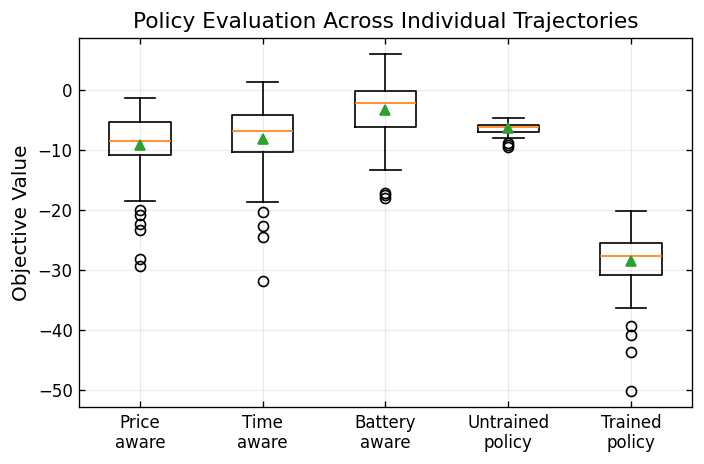

In [37]:
import matplotlib.pyplot as plt

res = torch.load(
    "../checkpoints/evaluations/policy_comparison_single.pt",
    weights_only=False
)

single_Js = res["Js"]

pretty_names = [
    name.replace("_", "\n").capitalize() for name in policy_names
]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [v for v in single_Js.values()],
    tick_labels=pretty_names,
    showmeans=True
)

plt.ylabel("Objective Value")
plt.title("Policy Evaluation Across Individual Trajectories")
plt.tight_layout()
plt.savefig("../figures/policy_comparison/policy_evaluation_single.pdf", bbox_inches="tight")
plt.show()

In [35]:
import numpy as np

seeds = range(10000, 10100)

policy_names = [
    "price_aware", "time_aware", "battery_aware", 
    "untrained_policy", "trained_policy"
]
policies = [
    PriceAwarePolicy(), TimeAwarePolicy(), BatteryAwarePolicy(),
    untrained_policy, trained_policy
]

multiple_Js = {name: [] for name in policy_names}

for seed in seeds:

    if seed % 10 == 0:
        print(f"Processed {seed-10000}/{len(seeds)} seeds")

    for name, policy in zip(policy_names, policies):

        next_price_fn = make_price_function(price_history, future_price, params)

        hist = rollout_trajectory(
            policy=policy,
            S0=S0,
            params=params,
            next_price_fn=next_price_fn,
            stochastic=True,
            alpha_grid=0.0,
            lambda_demand=0.0,
            lambda_cost=0.0,
            seed=seed,
            device=device,
        )

        multiple_Js[name].append(hist["J_episode"].item())


multiple_Js = {k: np.array(v) for k, v in multiple_Js.items()}

Processed 0/100 seeds
Processed 10/100 seeds
Processed 20/100 seeds
Processed 30/100 seeds
Processed 40/100 seeds
Processed 50/100 seeds
Processed 60/100 seeds
Processed 70/100 seeds
Processed 80/100 seeds
Processed 90/100 seeds


In [38]:
from pathlib import Path
import torch

save_dir = Path("../checkpoints/evaluations")
save_dir.mkdir(parents=True, exist_ok=True)

torch.save(
    {
        "Js": multiple_Js,
        "policy_names": policy_names,
        "seeds": list(seeds),
        "n_scenarios": len(seeds),
        "stochastic": True,
        "alpha_grid": 0.0,
        "lambda_cost": 0.0,
        "lambda_demand": 0.0,
    },
    save_dir / "policy_comparison_multiple.pt"
)

In [39]:
header = f"{'Metric':<10}"
for name in multiple_Js:
    header += f"{name:>12}"

print(header)
print("-" * len(header))

for metric, func in {
    "Mean J": np.mean,
    "Std J": np.std,
    "Min J": np.min,
    "Max J": np.max,
}.items():

    row = f"{metric:<10}"

    for values in multiple_Js.values():
        row += f"{func(values):>12.4f}"

    print(row)

Metric     price_aware  time_awarebattery_awareuntrained_policytrained_policy
-----------------------------------------------------------------------------
Mean J         -8.3933     -7.4661     -2.6442     -6.2245    -27.6545
Std J           0.1866      0.1960      0.1708      0.0285      0.1501
Min J          -8.8488     -7.9604     -3.0755     -6.3038    -28.0115
Max J          -7.9731     -6.9786     -2.2515     -6.1662    -27.0289


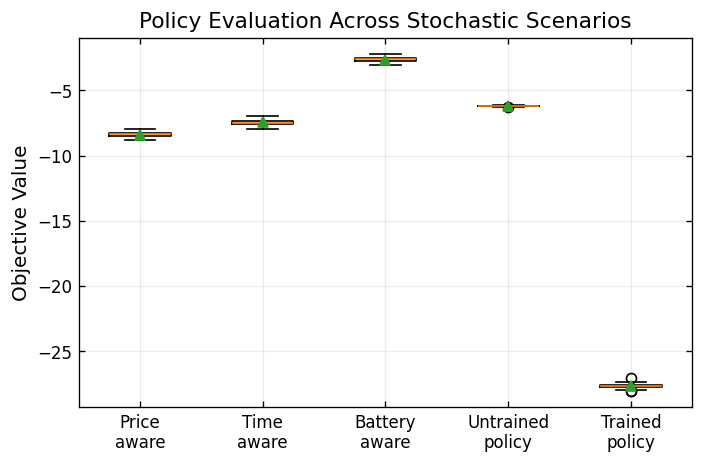

In [40]:
res2 = torch.load(
    "../checkpoints/evaluations/policy_comparison_multiple.pt",
    weights_only=False
)

multiple_Js = res2["Js"]

save_dir = Path("../figures/policy_comparison")
save_dir.mkdir(parents=True, exist_ok=True)

pretty_names = [
    name.replace("_", "\n").capitalize() for name in policy_names
]

plt.figure(figsize=(6, 4))

plt.boxplot(
    [v for v in multiple_Js.values()],
    tick_labels=pretty_names,
    showmeans=True
)

plt.ylabel("Objective Value")
plt.title("Policy Evaluation Across Stochastic Scenarios")
plt.tight_layout()
plt.savefig(save_dir / "policy_evaluation_multiple.pdf", bbox_inches="tight")
plt.show()